In [1]:
import pandas as pd
import numpy as np
import torch
from pathlib import Path

# Import survival analysis tools
from sksurv.metrics import concordance_index_censored
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv

# Import plotting tools
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

✅ Successfully loaded and aggregated to patient-level.
✅ Mapped TCGA datasets to organ groups.


/tmp/ipykernel_2451522/894423409.py:42: DtypeWarning: Columns (10,11,16,67) have mixed types. Specify dtype option on import or set low_memory=False.
  treatment_df = pd.read_csv(treatment_file_path, sep='\t')
/tmp/ipykernel_2451522/894423409.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patient_df_for_treatment['treatment'].fillna('Unknown', inplace=True)


✅ Created separate DataFrame for treatment analysis.
✅ Successfully loaded reference data from 4591 training samples.

                  Overall Cohort-Wide Performance

--- Overall Time-Dependent AUC Results (Entire Cohort) ---


Model,Breast Model,Colon Model
Landmark,,
12-Month,0.720054,0.795079
18-Month,0.746735,0.792370
3-Month,0.707654,0.823624
6-Month,0.773358,0.826991



--- Overall C-Index Results (Entire Cohort) ---


...

AUC             Positive Events            
Model           Breast Model Colon Model    Breast Model Colon Model
Organ  Landmark                                                     
Breast 12-Month     0.512635    0.801491             6.0         6.0
       18-Month     0.535966    0.773844             7.0         7.0
       3-Month      0.308176    0.645570             1.0         1.0
       6-Month      0.312102    0.647436             1.0         1.0
Colon  12-Month     0.491824    0.756371            14.0        13.0
       18-Month     0.576234    0.696932            18.0        17.0
       3-Month      0.586917    0.817924             6.0         6.0
       6-Month      0.603836    0.736073             9.0         8.0
Lung   12-Month     0.619668    0.701673            29.0        29.0
       18-Month     0.582514    0.683619            40.0        40.0
       3-Month      0.663875    0.897655             7.0         7.0
       6-Month      0.678341    0.772269            16.0        16.0


--- Grouped C-Index Results (Per Organ) ---


Model,Breast Model,Colon Model
Organ,,
Breast,0.512218,0.692631
Colon,0.551555,0.697353
Lung,0.586460,0.676501



--- Stratified C-Index Results with Counts (Per Treatment) ---


C-Index             Patient Count              \
Model                     Breast Model Colon Model  Breast Model Colon Model   
Treatment                                                                      
'--                           0.669730    0.728680        1219.0      1196.0   
Anastrozole                   0.505155    0.783505          33.0        33.0   
Capecitabine                  0.346154    0.538462          11.0        11.0   
Carboplatin                   0.685714    0.723810          21.0        21.0   
Cisplatin                     0.549020    0.647059          15.0        15.0   
Cyclophosphamide              0.402496    0.693164          96.0        95.0   
Docetaxel                     0.534091    0.755682          42.0        42.0   
Doxorubicin                   1.000000    0.933333          33.0        32.0   
Doxorubicin Hydrochloride     0.398693    0.745098          41.0        41.0   
Fluorouracil                  0.520566    0.667791          58.0        52.0   
Letrozole                     0.608696    0.913043          21.0        21.0   
Leucovorin                    0.214286    0.600000          15.0        13.0   
Leucovorin Calcium            0.341463    0.371429          12.0        11.0   
Oxaliplatin                   0.349515    0.625000          19.0        16.0   
Paclitaxel                    0.797189    0.864198          55.0        54.0   
Tamoxifen                     0.580247    0.703704          44.0        44.0   
Trastuzumab                   0.162162    0.621622          20.0        20.0   

                             Positives              
Model                     Breast Model Colon Model  
Treatment                                           
'--                              567.0       547.0  
Anastrozole                        4.0         4.0  
Capecitabine                       7.0         7.0  
Carboplatin                        8.0         8.0  
Cisplatin                          6.0         6.0  
Cyclophosphamide                  12.0        12.0  
Docetaxel                          7.0         7.0  
Doxorubicin                        1.0         1.0  
Doxorubicin Hydrochloride          8.0         8.0  
Fluorouracil                      26.0        21.0  
Letrozole                          3.0         3.0  
Leucovorin                         9.0         7.0  
Leucovorin Calcium                 8.0         8.0  
Oxaliplatin                       11.0         9.0  
Paclitaxel                        12.0        12.0  
Tamoxifen                          4.0         4.0  
Trastuzumab                        2.0         2.0

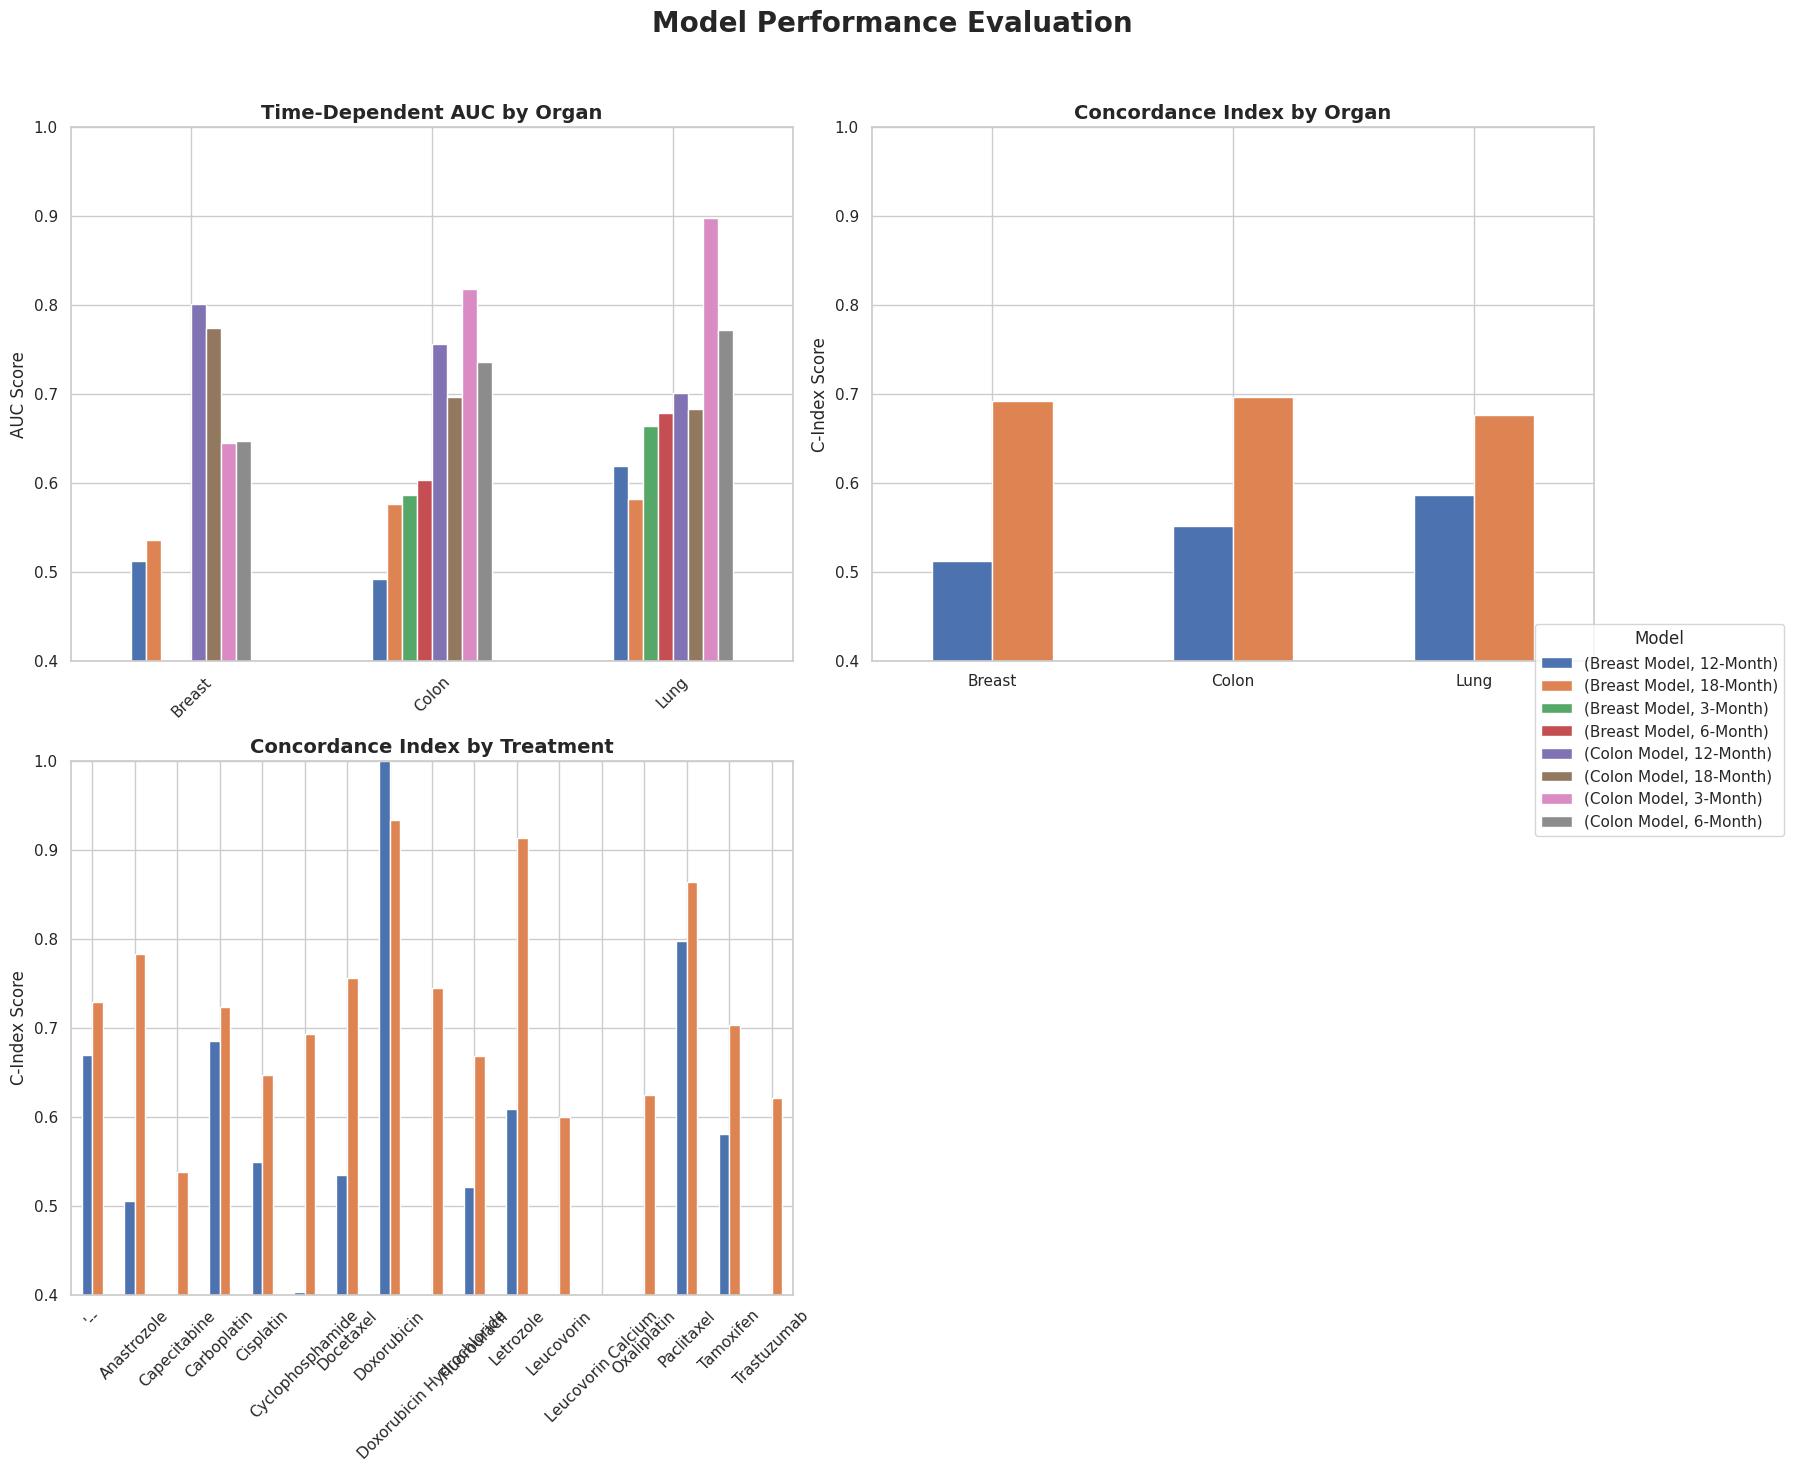

In [2]:
breast_preds_path = Path("eval_outputs/colon_model.csv")
colon_preds_path = Path("eval_outputs/test_set.csv")
split_file_path = Path("data/final_splits_prog_rec.pt")
clinical_csv_path = Path("data/outcomes/clinical_data_prog_rec_death.csv")
treatment_file_path = Path("data/clinical.tsv")

# This path should match the one used during training
feature_dir = Path("/storage/azizayed/features_hoptimus1")

# --- Evaluation Parameters ---
LANDMARK_MONTHS = [3, 6, 12, 18]
LANDMARK_DAYS = [m * 30.5 for m in LANDMARK_MONTHS]


# --- 1. Load, Aggregate, and Merge Data ---
try:
    # Load slide-level prediction files
    breast_df_slides = pd.read_csv(breast_preds_path)
    colon_df_slides = pd.read_csv(colon_preds_path)

    # Define aggregation function for patient-level risk
    agg_functions = {'risk_score': 'mean', 'time': 'first', 'event': 'first', 'dataset': 'first'}

    # Aggregate each model's data separately to the patient level
    breast_df_patients = breast_df_slides.groupby('patient_id').agg(agg_functions).reset_index()
    colon_df_patients = colon_df_slides.groupby('patient_id').agg(agg_functions).reset_index()

    # Add the model source column AFTER aggregation
    breast_df_patients['model_source'] = 'Breast Model'
    colon_df_patients['model_source'] = 'Colon Model'
    
    # Combine the two patient-level dataframes
    patient_df_unique = pd.concat([breast_df_patients, colon_df_patients], ignore_index=True)
    print("✅ Successfully loaded and aggregated to patient-level.")

    # Map TCGA datasets to organ groups
    organ_map = {'TCGA-LUAD': 'Lung', 'TCGA-LUSC': 'Lung', 'TCGA-READ': 'Colon', 'TCGA-COAD': 'Colon', 'TCGA-BRCA': 'Breast'}
    patient_df_unique['organ'] = patient_df_unique['dataset'].map(organ_map)
    print("✅ Mapped TCGA datasets to organ groups.")
    
    # Load treatment data
    treatment_df = pd.read_csv(treatment_file_path, sep='\t')
    treatment_df = treatment_df[['cases.submitter_id', 'treatments.therapeutic_agents']].rename(columns={
        'cases.submitter_id': 'patient_id',
        'treatments.therapeutic_agents': 'treatment'
    })
    
    # Create a new DataFrame for treatment analysis by merging, which may create duplicate patient rows
    patient_df_for_treatment = pd.merge(patient_df_unique, treatment_df, on='patient_id', how='left')
    
    # Clean up treatment data
    patient_df_for_treatment['treatment'].fillna('Unknown', inplace=True)
    patient_df_for_treatment['treatment'] = patient_df_for_treatment['treatment'].replace("Chemotherapy, NOS", "Chemotherapy")
    print("✅ Created separate DataFrame for treatment analysis.")
    

except FileNotFoundError as e:
    print(f"🛑 Error: {e}. Please ensure file paths in the configuration section are correct.")
    patient_df_unique = None

# --- 2. Load Training Data for td-AUC Reference ---
if patient_df_unique is not None:
    try:
        all_splits = torch.load(split_file_path, weights_only=False)
        train_paths_raw = all_splits[0]
        train_paths = [feature_dir / Path(p).name for p in train_paths_raw]
        clinical_df = pd.read_csv(clinical_csv_path, dtype={"patient_id": str}).set_index("patient_id")
        train_pids = ["-".join(p.name.split("-")[:3]) for p in train_paths]
        train_subset_df = clinical_df.loc[train_pids]
        y_train_reference = Surv.from_arrays(
            event=train_subset_df["progression_recurrence_event"],
            time=train_subset_df["max_follow_up_days"].where(train_subset_df["progression_recurrence_event"] == 0, train_subset_df["days_to_progression_recurrence"])
        )
        print(f"✅ Successfully loaded reference data from {len(y_train_reference)} training samples.")
    except Exception as e:
        print(f"🛑 Error loading reference data: {e}")
        patient_df_unique = None

# --- 3. Run Analysis ---
if patient_df_unique is not None:
    
    # --- Use the UNIQUE patient DataFrame for cohort-wide metrics ---
    print("\n" + "="*50)
    print("                  Overall Cohort-Wide Performance")
    print("="*50)
    
    # Cohort-wide AUC
    results_auc_cohort = []
    for model_name, model_group in patient_df_unique.groupby('model_source'):
        if not np.any(model_group['event'] == 1): continue
        y_eval_cohort = Surv.from_arrays(event=model_group['event'], time=model_group['time'])
        risk_scores_cohort = model_group['risk_score']
        auc_scores_cohort, _ = cumulative_dynamic_auc(y_train_reference, y_eval_cohort, risk_scores_cohort, LANDMARK_DAYS)
        for i, month in enumerate(LANDMARK_MONTHS):
            results_auc_cohort.append({'Model': model_name, 'Landmark': f'{month}-Month', 'AUC': auc_scores_cohort[i]})
    
    if results_auc_cohort:
        auc_cohort_df = pd.DataFrame(results_auc_cohort).pivot_table(index='Landmark', columns='Model', values='AUC')
        print("\n--- Overall Time-Dependent AUC Results (Entire Cohort) ---")
        display(auc_cohort_df)

    # Cohort-wide C-Index
    results_ci_cohort = []
    for model_name, model_group in patient_df_unique.groupby('model_source'):
        c_index_cohort = concordance_index_censored(event_indicator=model_group['event'].astype(bool), event_time=model_group['time'], estimate=model_group['risk_score'])[0]
        results_ci_cohort.append({'Model': model_name, 'C-Index': c_index_cohort, 'Num_Samples': len(model_group)})
    
    if results_ci_cohort:
        ci_cohort_df = pd.DataFrame(results_ci_cohort).set_index('Model')[['C-Index', 'Num_Samples']]
        print("\n--- Overall C-Index Results (Entire Cohort) ---")
        display(ci_cohort_df)

    # --- Use the UNIQUE patient DataFrame for stratified organ analyses ---
    print("\n" + "="*50)
    print("                        Stratified Performance")
    print("="*50)

    # AUC by Grouped Organ
    results_auc_grouped = []
    for model_name, model_group in patient_df_unique.groupby('model_source'):
        for organ_name, organ_group in model_group.groupby('organ'):
            if not np.any(organ_group['event'] == 1): continue
            y_eval_grouped = Surv.from_arrays(event=organ_group['event'], time=organ_group['time'])
            risk_scores_grouped = organ_group['risk_score']
            auc_scores_grouped, _ = cumulative_dynamic_auc(y_train_reference, y_eval_grouped, risk_scores_grouped, LANDMARK_DAYS)
            
            # ✨ NEW: Iterate through landmarks to get event counts
            for i, (month, day) in enumerate(zip(LANDMARK_MONTHS, LANDMARK_DAYS)):
                positive_events_at_landmark = organ_group.loc[
                    (organ_group['event'] == 1) & (organ_group['time'] <= day)
                ].shape[0]
                
                results_auc_grouped.append({
                    'Model': model_name, 
                    'Organ': organ_name, 
                    'Landmark': f'{month}-Month', 
                    'AUC': auc_scores_grouped[i],
                    'Positive Events': positive_events_at_landmark
                })

    # Create a detailed table for display
    auc_grouped_stats_df = pd.DataFrame(results_auc_grouped).pivot_table(
        index=['Organ', 'Landmark'], 
        columns='Model', 
        values=['AUC', 'Positive Events']
    )
    print("\n--- Grouped Time-Dependent AUC Results with Event Counts (Per Organ) ---")
    display(auc_grouped_stats_df)
    
    # Create a simpler table for plotting
    auc_grouped_df = pd.DataFrame(results_auc_grouped).pivot_table(
        index=['Organ', 'Landmark'], columns='Model', values='AUC'
    )

    # C-Index by Grouped Organ
    results_ci_organ = []
    for model_name, model_group in patient_df_unique.groupby('model_source'):
        for organ_name, organ_group in model_group.groupby('organ'):
            c_index = concordance_index_censored(event_indicator=organ_group['event'].astype(bool), event_time=organ_group['time'], estimate=organ_group['risk_score'])[0]
            results_ci_organ.append({'Model': model_name, 'Organ': organ_name, 'C-Index': c_index})
    ci_organ_df = pd.DataFrame(results_ci_organ).pivot_table(index='Organ', columns='Model', values='C-Index')
    print("\n--- Grouped C-Index Results (Per Organ) ---")
    display(ci_organ_df)

    # --- Use the EXPANDED patient DataFrame ONLY for treatment analysis ---
    if 'treatment' in patient_df_for_treatment.columns:
        results_ci_treatment = []
        for model_name, model_group in patient_df_for_treatment.groupby('model_source'):
            for treatment_name, treatment_group in model_group.groupby('treatment'):
                if len(treatment_group) < 10 or treatment_group['event'].sum() < 1: continue
                c_index_treatment = concordance_index_censored(event_indicator=treatment_group['event'].astype(bool), event_time=treatment_group['time'], estimate=treatment_group['risk_score'])[0]
                
                patient_count = len(treatment_group)
                positive_events = int(treatment_group['event'].sum())
                
                results_ci_treatment.append({
                    'Model': model_name, 
                    'Treatment': treatment_name, 
                    'C-Index': c_index_treatment,
                    'Patient Count': patient_count,
                    'Positives': positive_events
                })
        
        if results_ci_treatment:
            # Create a detailed table with stats for display
            ci_treatment_stats_df = pd.DataFrame(results_ci_treatment).pivot_table(
                index='Treatment', 
                columns='Model', 
                values=['C-Index', 'Patient Count', 'Positives']
            )
            print("\n--- Stratified C-Index Results with Counts (Per Treatment) ---")
            display(ci_treatment_stats_df)

            # Create a simple C-Index-only table for plotting
            ci_treatment_df = pd.DataFrame(results_ci_treatment).pivot_table(
                index='Treatment', columns='Model', values='C-Index'
            )

    # --- 4. Visualize Results ---
    fig, axes = plt.subplots(2, 2, figsize=(18, 15))
    fig.suptitle('Model Performance Evaluation', fontsize=20, weight='bold')

    # Plot 1: Per-Organ AUC
    auc_grouped_df.unstack().plot(kind='bar', ax=axes[0, 0], rot=45)
    axes[0, 0].set_title('Time-Dependent AUC by Organ', fontsize=14, weight='bold')
    axes[0, 0].set_ylabel('AUC Score')
    axes[0, 0].set_xlabel('')
    axes[0, 0].set_ylim(0.4, 1.0)
    
    # Plot 2: Per-Organ C-Index
    ci_organ_df.plot(kind='bar', ax=axes[0, 1], rot=0)
    axes[0, 1].set_title('Concordance Index by Organ', fontsize=14, weight='bold')
    axes[0, 1].set_ylabel('C-Index Score')
    axes[0, 1].set_xlabel('')
    axes[0, 1].set_ylim(0.4, 1.0)

    # Plot 3: Per-Treatment C-Index
    if 'ci_treatment_df' in locals() and not ci_treatment_df.empty:
        ci_treatment_df.plot(kind='bar', ax=axes[1, 0], rot=45)
        axes[1, 0].set_title('Concordance Index by Treatment', fontsize=14, weight='bold')
        axes[1, 0].set_ylabel('C-Index Score')
        axes[1, 0].set_xlabel('')
        axes[1, 0].set_ylim(0.4, 1.0)
    else:
        axes[1, 0].text(0.5, 0.5, 'No sufficient data for\ntreatment analysis', ha='center', va='center', fontsize=12)
        axes[1, 0].set_title('Concordance Index by Treatment', fontsize=14, weight='bold')
        axes[1, 0].axis('off')
        
    # Remove the 4th subplot axis
    axes[1, 1].axis('off')

    # Create a single legend for the figure
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='center right', title='Model', bbox_to_anchor=(1.0, 0.5))
    axes[0, 0].get_legend().remove()
    axes[0, 1].get_legend().remove()
    if 'ci_treatment_df' in locals() and not ci_treatment_df.empty:
        axes[1, 0].get_legend().remove()

    plt.tight_layout(rect=[0, 0, 0.9, 0.96]) # Adjust layout
    plt.show()

In [12]:
patient_df_for_treatment[(patient_df_for_treatment["dataset"] == "TCGA-BRCA")]["treatment"].value_counts()

treatment
'--                                              1022
Cyclophosphamide                                  191
Tamoxifen                                          88
Paclitaxel                                         87
Doxorubicin Hydrochloride                          82
Docetaxel                                          74
Anastrozole                                        66
Doxorubicin                                        65
Letrozole                                          42
Trastuzumab                                        40
Fluorouracil                                       36
Epirubicin                                         18
Exemestane                                         14
Methotrexate                                       10
Zoledronic Acid                                    10
Capecitabine                                        8
Carboplatin                                         8
Bevacizumab                                         4
Gemcitabine       

In [6]:
# Count patients with Anastrozole + each chemo, plus single-agent counts
# Assumes `patient_df_for_treatment` exists with columns: ['patient_id', 'treatment']

import pandas as pd
import re

# --- Safety check ---
if 'patient_df_for_treatment' not in globals():
    raise RuntimeError("`patient_df_for_treatment` not found. Run the cell that creates it first.")

# Keep only what we need and normalize
df = patient_df_for_treatment[['patient_id', 'treatment']].copy()
df['patient_id'] = df['patient_id'].astype(str)
df['treatment'] = df['treatment'].fillna('Unknown').astype(str)

# Aggregate all raw treatment strings per patient into one lowercase blob
agg = (
    df.groupby('patient_id')['treatment']
      .apply(lambda s: ' | '.join(sorted(set(map(str, s)))) )
      .str.lower()
      .reset_index(name='all_treatments_lc')
)

# Define patterns (include common aliases)
drug_patterns = {
    'Anastrozole': [r'\banastrozole\b'],
    'Paclitaxel':  [r'\bpaclitaxel\b', r'\btaxol\b'],
    'Docetaxel':   [r'\bdocetaxel\b', r'\btaxotere\b'],
    'Cyclophosphamide': [r'\bcyclophosphamide\b'],
    'Doxorubicin Hydrochloride': [r'\bdoxorubicin hydrochloride\b', r'\bdoxorubicin\b', r'\bdoxorubicin hcl\b'],
}

def has_any(text: str, pats):
    return any(re.search(p, text) is not None for p in pats)

# Create per-drug boolean flags per patient
for drug, pats in drug_patterns.items():
    agg[drug] = agg['all_treatments_lc'].apply(lambda t: bool(has_any(t, pats)))

# Helper: how many of the 5 drugs each patient received (for single-agent calc)
drug_cols = list(drug_patterns.keys())
agg['num_of_interest'] = agg[drug_cols].sum(axis=1)

# (A) Anastrozole + X counts, and exclusives
rows = []
for other in ['Paclitaxel', 'Docetaxel', 'Cyclophosphamide', 'Doxorubicin Hydrochloride']:
    both = int((agg['Anastrozole'] & agg[other]).sum())
    anas_only_vs_other = int((agg['Anastrozole'] & ~agg[other]).sum())
    other_only_vs_anas = int((agg[other] & ~agg['Anastrozole']).sum())
    rows.append({
        'Combination': f'Anastrozole + {other}',
        'Patients (both)': both,
        'Anastrozole only (vs this other)': anas_only_vs_other,
        f'{other} only (vs Anastrozole)': other_only_vs_anas
    })
combos_df = pd.DataFrame(rows).sort_values('Patients (both)', ascending=False).reset_index(drop=True)

# (B) Single-agent (exactly one of the five drugs)
singles_df = (
    pd.DataFrame({
        'Drug (single-agent among the set)': drug_cols,
        'Patients': [int((agg[d] & (agg['num_of_interest'] == 1)).sum()) for d in drug_cols]
    })
    .sort_values('Patients', ascending=False)
    .reset_index(drop=True)
)

# (C) Totals (any exposure per drug)
totals_df = (
    pd.DataFrame({
        'Drug (any exposure)': drug_cols,
        'Patients': [int(agg[d].sum()) for d in drug_cols]
    })
    .sort_values('Patients', ascending=False)
    .reset_index(drop=True)
)

print("\n=== Anastrozole combination counts ===")
combos_df

#print("\n=== Single-agent counts (exactly one of the five) ===")
#print(singles_df.to_string(index=False))

#print("\n=== Total patients with any exposure (per drug) ===")
#print(totals_df.to_string(index=False))



=== Anastrozole combination counts ===


,Combination,Patients (both),Anastrozole only (vs this other),Paclitaxel only (vs Anastrozole),Docetaxel only (vs Anastrozole),Cyclophosphamide only (vs Anastrozole),Doxorubicin Hydrochloride only (vs Anastrozole)
0,Anastrozole + Cyclophosphamide,19,12,NaN,NaN,76.0,NaN
1,Anastrozole + Doxorubicin Hydrochloride,17,14,NaN,NaN,NaN,54.0
2,Anastrozole + Paclitaxel,13,18,41.0,NaN,NaN,NaN
3,Anastrozole + Docetaxel,8,23,NaN,34.0,NaN,NaN


✅ Successfully loaded and aggregated to patient-level.
✅ Mapped TCGA datasets to organ groups.
✅ Created separate DataFrame for treatment analysis.
✅ Successfully loaded reference data from 4591 training samples.
[drop] /data/rbg/users/azizayed/chemistry/mil_explain_pkg/new_metrics_out/drops_overall_bottom20_n_cells_patients.csv: 14 patients
[drop] Total unique patients to drop: 14
[keep] patient_df_unique: 771/799 patients kept (28 dropped)
[keep] patient_df_for_treatment: 3497/3661 patients kept (164 dropped)

[by organ] kept counts:
organ
Breast    323
Colon     193
Lung      255
Name: count, dtype: int64
[ok] wrote eval_outputs/dropped_patients_union.csv

                  Overall Cohort-Wide Performance (FILTERED)


/tmp/ipykernel_4154937/3855503415.py:42: DtypeWarning: Columns (10,11,16,67) have mixed types. Specify dtype option on import or set low_memory=False.
  treatment_df = pd.read_csv(treatment_file_path, sep='\t')
/tmp/ipykernel_4154937/3855503415.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  patient_df_for_treatment['treatment'].fillna('Unknown', inplace=True)


Model,Breast Model,Colon Model
Landmark,,
12-Month,0.725239,0.795696
18-Month,0.748263,0.795603
3-Month,0.711000,0.823631
6-Month,0.769747,0.821309


,C-Index,Num_Samples
Model,,
Breast Model,0.713093,388
Colon Model,0.765779,383



                        Stratified Performance (FILTERED)


AUC             Positive Events            
Model           Breast Model Colon Model    Breast Model Colon Model
Organ  Landmark                                                     
Breast 12-Month     0.521164    0.815287             6.0         6.0
       18-Month     0.541614    0.784821             7.0         7.0
       3-Month      0.322368    0.662252             1.0         1.0
       6-Month      0.326667    0.664430             1.0         1.0
Colon  12-Month     0.527633    0.780348            13.0        12.0
       18-Month     0.606423    0.711711            17.0        16.0
       3-Month      0.584108    0.815806             6.0         6.0
       6-Month      0.600481    0.734464             9.0         8.0
Lung   12-Month     0.629427    0.695070            28.0        28.0
       18-Month     0.590229    0.695819            38.0        38.0
       3-Month      0.677312    0.899362             7.0         7.0
       6-Month      0.683937    0.767819            15.0        15.0

Model,Breast Model,Colon Model
Organ,,
Breast,0.510727,0.709216
Colon,0.572989,0.706743
Lung,0.591977,0.680154


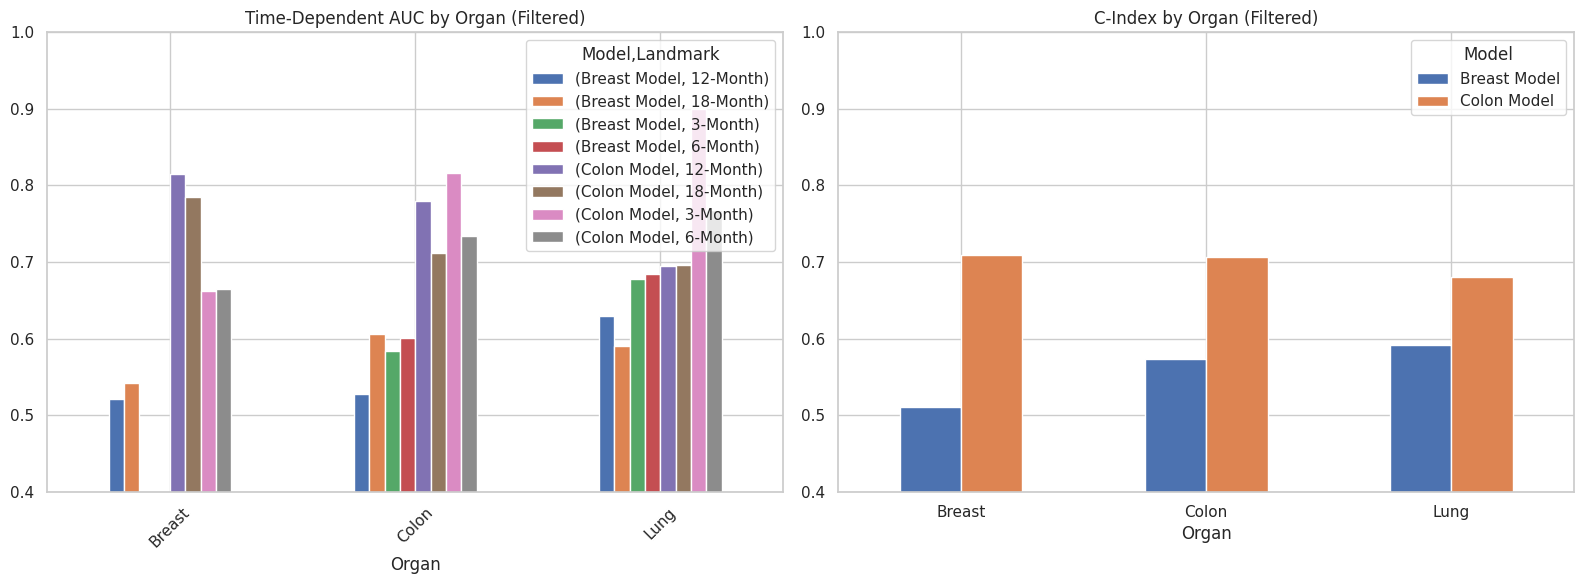

In [60]:
breast_preds_path = Path("eval_outputs/colon_model.csv")
colon_preds_path = Path("eval_outputs/test_set.csv")
split_file_path = Path("data/final_splits_prog_rec.pt")
clinical_csv_path = Path("data/outcomes/clinical_data_prog_rec_death.csv")
treatment_file_path = Path("data/clinical.tsv")

# This path should match the one used during training
feature_dir = Path("/storage/azizayed/features_hoptimus1")

# --- Evaluation Parameters ---
LANDMARK_MONTHS = [3, 6, 12, 18]
LANDMARK_DAYS = [m * 30.5 for m in LANDMARK_MONTHS]


# --- 1. Load, Aggregate, and Merge Data ---
try:
    # Load slide-level prediction files
    breast_df_slides = pd.read_csv(breast_preds_path)
    colon_df_slides = pd.read_csv(colon_preds_path)

    # Define aggregation function for patient-level risk
    agg_functions = {'risk_score': 'mean', 'time': 'first', 'event': 'first', 'dataset': 'first'}

    # Aggregate each model's data separately to the patient level
    breast_df_patients = breast_df_slides.groupby('patient_id').agg(agg_functions).reset_index()
    colon_df_patients = colon_df_slides.groupby('patient_id').agg(agg_functions).reset_index()

    # Add the model source column AFTER aggregation
    breast_df_patients['model_source'] = 'Breast Model'
    colon_df_patients['model_source'] = 'Colon Model'
    
    # Combine the two patient-level dataframes
    patient_df_unique = pd.concat([breast_df_patients, colon_df_patients], ignore_index=True)
    print("✅ Successfully loaded and aggregated to patient-level.")

    # Map TCGA datasets to organ groups
    organ_map = {'TCGA-LUAD': 'Lung', 'TCGA-LUSC': 'Lung', 'TCGA-READ': 'Colon', 'TCGA-COAD': 'Colon', 'TCGA-BRCA': 'Breast'}
    patient_df_unique['organ'] = patient_df_unique['dataset'].map(organ_map)
    print("✅ Mapped TCGA datasets to organ groups.")
    
    # Load treatment data
    treatment_df = pd.read_csv(treatment_file_path, sep='\t')
    treatment_df = treatment_df[['cases.submitter_id', 'treatments.therapeutic_agents']].rename(columns={
        'cases.submitter_id': 'patient_id',
        'treatments.therapeutic_agents': 'treatment'
    })
    
    # Create a new DataFrame for treatment analysis by merging, which may create duplicate patient rows
    patient_df_for_treatment = pd.merge(patient_df_unique, treatment_df, on='patient_id', how='left')
    
    # Clean up treatment data
    patient_df_for_treatment['treatment'].fillna('Unknown', inplace=True)
    patient_df_for_treatment['treatment'] = patient_df_for_treatment['treatment'].replace("Chemotherapy, NOS", "Chemotherapy")
    print("✅ Created separate DataFrame for treatment analysis.")
    

except FileNotFoundError as e:
    print(f"🛑 Error: {e}. Please ensure file paths in the configuration section are correct.")
    patient_df_unique = None

# --- 2. Load Training Data for td-AUC Reference ---
if patient_df_unique is not None:
    try:
        all_splits = torch.load(split_file_path, weights_only=False)
        train_paths_raw = all_splits[0]
        train_paths = [feature_dir / Path(p).name for p in train_paths_raw]
        clinical_df = pd.read_csv(clinical_csv_path, dtype={"patient_id": str}).set_index("patient_id")
        train_pids = ["-".join(p.name.split("-")[:3]) for p in train_paths]
        train_subset_df = clinical_df.loc[train_pids]
        y_train_reference = Surv.from_arrays(
            event=train_subset_df["progression_recurrence_event"],
            time=train_subset_df["max_follow_up_days"].where(
                train_subset_df["progression_recurrence_event"] == 0,
                train_subset_df["days_to_progression_recurrence"]
            )
        )
        print(f"✅ Successfully loaded reference data from {len(y_train_reference)} training samples.")
    except Exception as e:
        print(f"🛑 Error loading reference data: {e}")
        patient_df_unique = None

# === Patient-level drops (run only if data is loaded) ===
if patient_df_unique is not None:
    from pathlib import Path
    import pandas as pd
    import glob

    # EITHER: explicit list (your current approach)
    DROP_FILES = [
        #"/data/rbg/users/azizayed/chemistry/mil_explain_pkg/new_metrics_out/drops_overall_bottom20_cells_in_hot_patients.csv",
        "/data/rbg/users/azizayed/chemistry/mil_explain_pkg/new_metrics_out/drops_overall_bottom20_n_cells_patients.csv",
        #"/data/rbg/users/azizayed/chemistry/mil_explain_pkg/new_metrics_out/drops_overall_bottom20_n_cells.csv"
        # add more here if needed
    ]

    # OR: auto-discover all patient drop files (optional convenience)
    # DROP_FILES = sorted(glob.glob("/data/rbg/users/azizayed/chemistry/mil_explain_pkg/new_metrics_out/drops_*_patients.csv"))

    def read_patient_ids(fp: str | Path) -> pd.Series:
        df = pd.read_csv(fp)
        cols = {c.lower(): c for c in df.columns}
        if "patient_id" in cols:
            s = df[cols["patient_id"]].astype(str)
        elif "slide_id" in cols:
            # Map slide_id -> TCGA patient by first 3 hyphen chunks
            s = df[cols["slide_id"]].astype(str).str.split("-").str[:3].str.join("-")
        elif "path" in cols:
            s = (df[cols["path"]].astype(str)
                 .apply(lambda p: Path(p).stem.split(".")[0])
                 .str.split("-").str[:3].str.join("-"))
        else:
            raise ValueError(f"Don’t know how to read patient IDs from {fp}; expected one of: patient_id, slide_id, path")
        return s.dropna().str.strip()

    drop_patients = set()
    for fp in DROP_FILES:
        try:
            ids = read_patient_ids(fp)
            drop_patients.update(ids.tolist())
            print(f"[drop] {fp}: {len(ids)} patients")
        except Exception as e:
            print(f"[warn] Could not read {fp}: {e}")

    drop_patients = {pid for pid in drop_patients if pid}
    print(f"[drop] Total unique patients to drop: {len(drop_patients)}")

    def apply_patient_drop(df: pd.DataFrame, label: str) -> pd.DataFrame:
        before = len(df)
        out = df[~df["patient_id"].astype(str).isin(drop_patients)].copy()
        after = len(out)
        print(f"[keep] {label}: {after}/{before} patients kept ({before-after} dropped)")
        return out

    patient_df_unique_filtered = apply_patient_drop(patient_df_unique, "patient_df_unique")
    if 'patient_df_for_treatment' in locals() and patient_df_for_treatment is not None:
        patient_df_for_treatment_filtered = apply_patient_drop(patient_df_for_treatment, "patient_df_for_treatment")
    else:
        patient_df_for_treatment_filtered = None

    if "organ" in patient_df_unique_filtered.columns:
        print("\n[by organ] kept counts:")
        print(patient_df_unique_filtered["organ"].value_counts().sort_index())

    # Use the filtered frames downstream
    patient_df_unique = patient_df_unique_filtered
    patient_df_for_treatment = patient_df_for_treatment_filtered

    # Save provenance
    out_dir = Path("eval_outputs"); out_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(sorted(drop_patients), columns=["patient_id"]).to_csv(out_dir / "dropped_patients_union.csv", index=False)
    patient_df_unique.to_csv(out_dir / "patient_df_unique_filtered.csv", index=False)
    if patient_df_for_treatment is not None:
        patient_df_for_treatment.to_csv(out_dir / "patient_df_for_treatment_filtered.csv", index=False)
    print(f"[ok] wrote {out_dir/'dropped_patients_union.csv'}")

# --- 3. Run Analysis on FILTERED cohort ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sksurv.util import Surv
from sksurv.metrics import cumulative_dynamic_auc, concordance_index_censored

assert patient_df_unique is not None, "patient_df_unique is None (upstream load failed)."

print("\n" + "="*50)
print("                  Overall Cohort-Wide Performance (FILTERED)")
print("="*50)

# Overall AUC at landmarks
results_auc_cohort = []
for model_name, model_group in patient_df_unique.groupby('model_source'):
    if not np.any(model_group['event'] == 1):
        continue
    y_eval = Surv.from_arrays(event=model_group['event'], time=model_group['time'])
    risk_scores = model_group['risk_score']
    auc_scores, _ = cumulative_dynamic_auc(y_train_reference, y_eval, risk_scores, LANDMARK_DAYS)
    for i, month in enumerate(LANDMARK_MONTHS):
        results_auc_cohort.append({'Model': model_name, 'Landmark': f'{month}-Month', 'AUC': auc_scores[i]})

if results_auc_cohort:
    auc_cohort_df = pd.DataFrame(results_auc_cohort).pivot_table(index='Landmark', columns='Model', values='AUC')
    display(auc_cohort_df)

# Overall C-index
results_ci_cohort = []
for model_name, model_group in patient_df_unique.groupby('model_source'):
    c_index = concordance_index_censored(
        event_indicator=model_group['event'].astype(bool),
        event_time=model_group['time'],
        estimate=model_group['risk_score']
    )[0]
    results_ci_cohort.append({'Model': model_name, 'C-Index': c_index, 'Num_Samples': len(model_group)})

if results_ci_cohort:
    ci_cohort_df = pd.DataFrame(results_ci_cohort).set_index('Model')[['C-Index', 'Num_Samples']]
    display(ci_cohort_df)

print("\n" + "="*50)
print("                        Stratified Performance (FILTERED)")
print("="*50)

# AUC by organ at landmarks
results_auc_grouped = []
for model_name, model_group in patient_df_unique.groupby('model_source'):
    for organ_name, organ_group in model_group.groupby('organ'):
        if not np.any(organ_group['event'] == 1):
            continue
        y_eval = Surv.from_arrays(event=organ_group['event'], time=organ_group['time'])
        risk_scores = organ_group['risk_score']
        auc_scores, _ = cumulative_dynamic_auc(y_train_reference, y_eval, risk_scores, LANDMARK_DAYS)
        for i, (month, day) in enumerate(zip(LANDMARK_MONTHS, LANDMARK_DAYS)):
            positives_at_landmark = organ_group.loc[(organ_group['event'] == 1) & (organ_group['time'] <= day)].shape[0]
            results_auc_grouped.append({
                'Model': model_name, 'Organ': organ_name,
                'Landmark': f'{month}-Month', 'AUC': auc_scores[i],
                'Positive Events': positives_at_landmark
            })

auc_grouped_stats_df = pd.DataFrame(results_auc_grouped).pivot_table(
    index=['Organ','Landmark'], columns='Model', values=['AUC','Positive Events']
)
display(auc_grouped_stats_df)

# C-index by organ
results_ci_organ = []
for model_name, model_group in patient_df_unique.groupby('model_source'):
    for organ_name, organ_group in model_group.groupby('organ'):
        c_index = concordance_index_censored(
            event_indicator=organ_group['event'].astype(bool),
            event_time=organ_group['time'],
            estimate=organ_group['risk_score']
        )[0]
        results_ci_organ.append({'Model': model_name, 'Organ': organ_name, 'C-Index': c_index})

ci_organ_df = pd.DataFrame(results_ci_organ).pivot_table(index='Organ', columns='Model', values='C-Index')
display(ci_organ_df)

# (Optional) Plots similar to your originals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pd.DataFrame(results_auc_grouped).pivot_table(index=['Organ','Landmark'], columns='Model', values='AUC') \
    .unstack().plot(kind='bar', ax=axes[0], rot=45)
axes[0].set_title('Time-Dependent AUC by Organ (Filtered)')
axes[0].set_ylim(0.4, 1.0)

ci_organ_df.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('C-Index by Organ (Filtered)')
axes[1].set_ylim(0.4, 1.0)

plt.tight_layout(); plt.show()

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [43]:
data = pd.read_csv("temporary/clinical_data_no_death_event.csv")

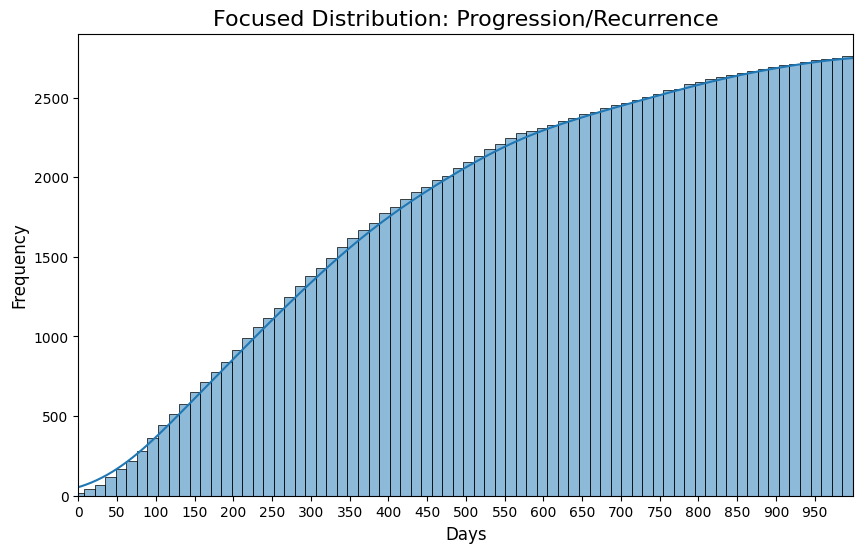

In [45]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a histogram with more bins for detail
sns.histplot(data[data['days_to_progression_recurrence'] <= 1000]['days_to_progression_recurrence'], kde=True, bins=100, cumulative=True)

# --- Add more ticks to the x-axis ---
# We'll set ticks for every 20 days from 0 to 180
plt.xticks(np.arange(0, 1000, 50))

# Add title and labels
plt.title('Focused Distribution: Progression/Recurrence', fontsize=16)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim((0, 1000))

# Display the plot
plt.show()

In [48]:
data[data["days_to_progression_recurrence"] <= 180]

,patient_id,project_id,days_to_progression_recurrence,max_follow_up_days,progression_recurrence_event,time
0,TCGA-02-0001,TCGA-GBM,137.0,358.0,1,137.0
1,TCGA-02-0003,TCGA-GBM,40.0,144.0,1,40.0
7,TCGA-02-0011,TCGA-GBM,145.0,630.0,1,145.0
18,TCGA-02-0033,TCGA-GBM,32.0,86.0,1,32.0
20,TCGA-02-0037,TCGA-GBM,37.0,110.0,1,37.0
...,...,...,...,...,...,...
11142,TCGA-ZG-A9L9,TCGA-PRAD,51.0,617.0,1,51.0
11155,TCGA-ZH-A8Y1,TCGA-CHOL,49.0,385.0,1,49.0
11194,TCGA-ZN-A9VW,TCGA-MESO,-30.0,84.0,1,-30.0
11203,TCGA-ZR-A9CJ,TCGA-ESCA,163.0,600.0,1,163.0


In [49]:
data = pd.read_csv("temporary/clinical_data_no_death_event_cptac.csv")

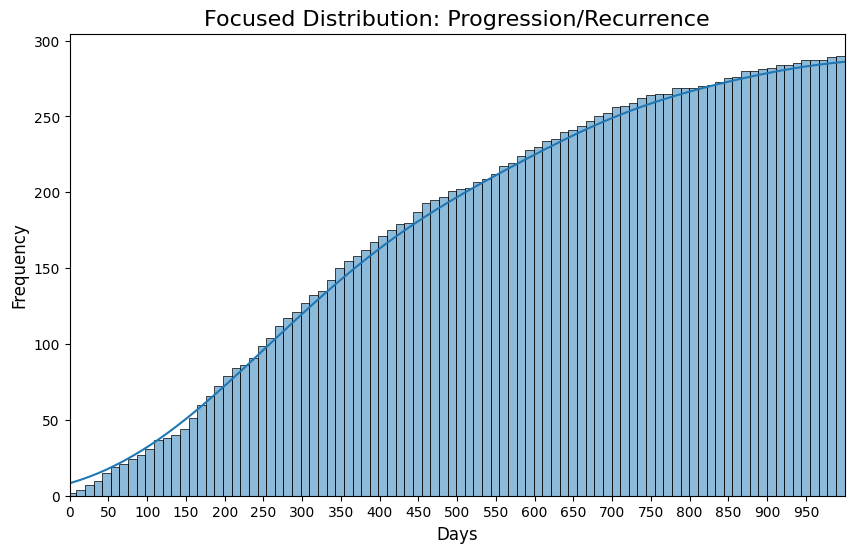

In [50]:
# Set the figure size
plt.figure(figsize=(10, 6))

# Create a histogram with more bins for detail
sns.histplot(data[data['days_to_progression_recurrence'] <= 1000]['days_to_progression_recurrence'], kde=True, bins=100, cumulative=True)

# --- Add more ticks to the x-axis ---
# We'll set ticks for every 20 days from 0 to 180
plt.xticks(np.arange(0, 1000, 50))

# Add title and labels
plt.title('Focused Distribution: Progression/Recurrence', fontsize=16)
plt.xlabel('Days', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim((0, 1000))

# Display the plot
plt.show()

In [40]:
# --- HRs with validation-derived thresholds (Youden J + tunable quantile), applied to TEST ---
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import display
import warnings

# External deps
try:
    from lifelines import CoxPHFitter
    from sklearn.metrics import roc_curve
except Exception as e:
    raise ImportError("Please install dependencies: `pip install lifelines scikit-learn`") from e

# ------------------ Config ------------------
VAL_PREDS_PATH  = Path("eval_outputs/val_set.csv")
TEST_PREDS_PATH = Path("eval_outputs/test_set.csv")

# Organ mapping (edit as needed)
organ_map = {
    'TCGA-LUAD': 'Lung', 'TCGA-LUSC': 'Lung',
    'TCGA-READ': 'Colon', 'TCGA-COAD': 'Colon',
    'TCGA-BRCA': 'Breast'
}

# Landmark for ROC/Youden labeling (months -> days)
HR_LANDMARK_MONTH = 12
HR_LANDMARK_DAYS  = int(30.5 * HR_LANDMARK_MONTH)

# Tunable quantile cutoff (e.g., 0.5=median, 0.75=top quartile)
QUANTILE_Q = 0.8

# Minimum size/event guardrails for fitting HRs
MIN_N = 10

# ------------------ Helpers ------------------
def _ensure_model_source(df, default_name="Model"):
    if 'model_source' in df.columns:
        return df
    # Try common alternatives
    for alt in ['model', 'source', 'model_name']:
        if alt in df.columns:
            df = df.rename(columns={alt: 'model_source'})
            return df
    df = df.copy()
    df['model_source'] = default_name
    return df

def _agg_to_patient(df):
    """Aggregate slide-level to patient-level: mean risk; first time/event/dataset/model_source."""
    agg_functions = {'risk_score': 'mean', 'time': 'first', 'event': 'first', 'dataset': 'first', 'model_source': 'first'}
    return (df.groupby('patient_id').agg(agg_functions).reset_index())

def _add_organ(df):
    df = df.copy()
    df['organ'] = df['dataset'].map(organ_map).fillna('Other')
    return df

def _binary_label_at_landmark(df, time_col='time', event_col='event', horizon_days=365):
    """1 if event occurs by horizon_days, else 0."""
    return ((df[event_col] == 1) & (df[time_col] <= horizon_days)).astype(int)

def _youden_cutoff(scores, labels):
    """Threshold maximizing Youden's J. Returns None if degenerate."""
    if len(scores) == 0 or len(labels) == 0:
        return None
    if labels.sum() == 0 or labels.sum() == len(labels):
        return None
    fpr, tpr, thr = roc_curve(labels, scores)
    j = tpr - fpr
    if len(j) == 0 or np.all(np.isnan(j)):
        return None
    return float(thr[np.nanargmax(j)])

def _quantile_cutoff(scores, q):
    """q-quantile threshold; returns None if empty/NaN."""
    s = pd.Series(scores).dropna()
    if s.empty:
        return None
    return float(s.quantile(q))

def _cox_hr_binary(df, time_col='time', event_col='event', group_col='group_high'):
    """Univariate CoxPH with binary group_high (1=High, 0=Low)."""
    use = df[[time_col, event_col, group_col]].dropna().copy()
    use = use[use[time_col] > 0]
    n = int(len(use))
    events = int(use[event_col].sum())
    # needs at least one event and two groups present
    if n < MIN_N or events < 1 or use[group_col].nunique() < 2:
        return {'N': n, 'Events': events, 'HR_HvsL': np.nan, 'CI_lower': np.nan, 'CI_upper': np.nan, 'p': np.nan}
    cph = CoxPHFitter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cph.fit(use, duration_col=time_col, event_col=event_col, show_progress=False)
    hr = float(cph.hazard_ratios_[group_col])
    log_ci_low, log_ci_high = cph.confidence_intervals_.loc[group_col].values.tolist()
    return {
        'N': n, 'Events': events,
        'HR_HvsL': hr,
        'CI_lower': float(np.exp(log_ci_low)),
        'CI_upper': float(np.exp(log_ci_high)),
        'p': float(cph.summary.loc[group_col, 'p'])
    }

# ------------------ Load & prepare ------------------
val_slides  = pd.read_csv(VAL_PREDS_PATH)
test_slides = pd.read_csv(TEST_PREDS_PATH)

val_slides  = _ensure_model_source(val_slides)
test_slides = _ensure_model_source(test_slides)

val_pat  = _add_organ(_agg_to_patient(val_slides))
test_pat = _add_organ(_agg_to_patient(test_slides))

# Sanity: unique patient counts per model on TEST
print("\n--- Unique TEST patients per model ---")
test_counts = test_pat.groupby('model_source')['patient_id'].nunique().rename('Unique Patients')
display(test_counts.to_frame())

# ------------------ Learn VAL cutoffs ------------------
print("\n" + "="*60)
print(f"Cutoff learning on VALIDATION (Youden J @ {HR_LANDMARK_MONTH} mo & quantile q={QUANTILE_Q})")
print("="*60)

youden_overall = {}          # model -> {'thr': ..., 'note': 'Youden'|'quantile_fallback'|'NA'}
youden_per_organ = {}        # model -> {organ -> {'thr': ..., 'note': ...}}
quantile_overall = {}        # model -> {'thr': ..., 'note': 'quantile'}
quantile_per_organ = {}      # model -> {organ -> {'thr': ..., 'note': 'quantile'}}

for model, g in val_pat.groupby('model_source'):
    # Overall labels
    labels = _binary_label_at_landmark(g, horizon_days=HR_LANDMARK_DAYS)
    thr_y = _youden_cutoff(g['risk_score'].values, labels.values)
    if thr_y is None:
        # Fallback to quantile if Youden not computable
        thr_q = _quantile_cutoff(g['risk_score'].values, QUANTILE_Q)
        youden_overall[model] = {'thr': thr_q, 'note': 'quantile_fallback'}
    else:
        youden_overall[model] = {'thr': thr_y, 'note': 'Youden'}

    # Also store pure quantile (for the quantile-based analysis)
    thr_q_overall = _quantile_cutoff(g['risk_score'].values, QUANTILE_Q)
    quantile_overall[model] = {'thr': thr_q_overall, 'note': 'quantile'}

    # Per-organ thresholds
    youden_per_organ[model] = {}
    quantile_per_organ[model] = {}
    for organ, gg in g.groupby('organ'):
        y = _binary_label_at_landmark(gg, horizon_days=HR_LANDMARK_DAYS)
        thr_org_y = _youden_cutoff(gg['risk_score'].values, y.values)
        if thr_org_y is None:
            # Fallback: organ quantile; if still None, fall back to model overall youden/quantile
            thr_org_q = _quantile_cutoff(gg['risk_score'].values, QUANTILE_Q)
            if thr_org_q is None:
                thr_org = youden_overall[model]['thr']
                note = f"fallback_to_model_{youden_overall[model]['note']}"
            else:
                thr_org = thr_org_q
                note = "quantile_fallback"
        else:
            thr_org = thr_org_y
            note = "Youden"
        youden_per_organ[model][organ] = {'thr': thr_org, 'note': note}

        # Also store organ-specific quantile for the quantile-based analysis
        thr_org_quant = _quantile_cutoff(gg['risk_score'].values, QUANTILE_Q)
        if thr_org_quant is None:
            thr_org_quant = quantile_overall[model]['thr']
            qnote = "fallback_to_model_quantile"
        else:
            qnote = "quantile"
        quantile_per_organ[model][organ] = {'thr': thr_org_quant, 'note': qnote}

# Display learned thresholds
print("\n--- Validation-derived overall cutoffs (per model) ---")
display(pd.DataFrame(youden_overall).T.rename(columns={'thr': 'threshold', 'note': 'type'}))
print("\n--- Validation-derived per-organ cutoffs (per model x organ) ---")
rows = []
for m, d in youden_per_organ.items():
    for org, info in d.items():
        rows.append({'Model': m, 'Organ': org, 'threshold': info['thr'], 'type': info['note']})
display(pd.DataFrame(rows).sort_values(['Model','Organ']).set_index(['Model','Organ']))

print("\n--- Validation-derived overall quantiles (per model) ---")
display(pd.DataFrame(quantile_overall).T.rename(columns={'thr': 'threshold', 'note': 'type'}))
print("\n--- Validation-derived per-organ quantiles (per model x organ) ---")
rows_q = []
for m, d in quantile_per_organ.items():
    for org, info in d.items():
        rows_q.append({'Model': m, 'Organ': org, 'threshold': info['thr'], 'type': info['note']})
display(pd.DataFrame(rows_q).sort_values(['Model','Organ']).set_index(['Model','Organ']))

# ------------------ Apply to TEST: HRs (Youden-based) ------------------
print("\n" + "="*60)
print("HRs on TEST using VALIDATION-derived Youden cutoffs")
print("="*60)

# Overall HRs per model
rows_overall = []
overall_counts = []
for model, g in test_pat.groupby('model_source'):
    thr = youden_overall[model]['thr']
    d = g.copy()
    d['group_high'] = (d['risk_score'] >= thr).astype(int)
    res = _cox_hr_binary(d)
    res.update({'Model': model, 'Cutoff': thr, 'Cutoff_type': youden_overall[model]['note']})
    rows_overall.append(res)

    # Counts by group at the landmark (for sanity)
    lbl = _binary_label_at_landmark(g, horizon_days=HR_LANDMARK_DAYS)
    is_high = (g['risk_score'] >= thr).astype(int)
    overall_counts.append({
        'Model': model,
        'N_total': int(len(g)),
        'High_N': int(is_high.sum()),
        'Low_N': int((1 - is_high).sum()),
        'High_events_by_landmark': int(((lbl == 1) & (is_high == 1)).sum()),
        'Low_events_by_landmark': int(((lbl == 1) & (is_high == 0)).sum()),
    })

print("\n--- TEST Overall HR (High vs Low) per model [Youden] ---")
display(pd.DataFrame(rows_overall).set_index('Model')[['Cutoff','Cutoff_type','N','Events','HR_HvsL','CI_lower','CI_upper','p']])

print("\n--- TEST Overall counts per model with Youden cutoff ---")
display(pd.DataFrame(overall_counts).set_index('Model'))

# Per-organ HRs per model
rows_org = []
for model, g in test_pat.groupby('model_source'):
    for organ, gg in g.groupby('organ'):
        thr = youden_overall[model]['thr']#youden_per_organ.get(model, {}).get(organ, {'thr': youden_overall[model]['thr'], 'note': 'fallback_to_model'})['thr']
        d = gg.copy()
        d['group_high'] = (d['risk_score'] >= thr).astype(int)
        res = _cox_hr_binary(d)
        res.update({'Model': model, 'Organ': organ, 'Cutoff': thr, 'Cutoff_type': youden_per_organ[model][organ]['note'] if organ in youden_per_organ[model] else 'fallback_to_model'})
        rows_org.append(res)

print("\n--- TEST Per-organ HR (High vs Low) [Youden] ---")
display(
    pd.DataFrame(rows_org)
      .sort_values(['Organ','Model'])
      .set_index(['Organ','Model'])[['Cutoff','Cutoff_type','N','Events','HR_HvsL','CI_lower','CI_upper','p']]
)

# ------------------ Apply to TEST: HRs (Quantile-based) ------------------
print("\n" + "="*60)
print(f"HRs on TEST using VALIDATION-derived quantile cutoffs (q={QUANTILE_Q})")
print("="*60)

# Overall quantile HRs per model
rows_overall_q = []
for model, g in test_pat.groupby('model_source'):
    thr = quantile_overall[model]['thr']
    d = g.copy()
    d['group_high'] = (d['risk_score'] >= thr).astype(int)
    res = _cox_hr_binary(d)
    res.update({'Model': model, 'Cutoff': thr, 'Cutoff_type': 'quantile'})
    rows_overall_q.append(res)

print("\n--- TEST Overall HR (High vs Low) per model [Quantile] ---")
display(pd.DataFrame(rows_overall_q).set_index('Model')[['Cutoff','Cutoff_type','N','Events','HR_HvsL','CI_lower','CI_upper','p']])

# Per-organ quantile HRs per model
rows_org_q = []
for model, g in test_pat.groupby('model_source'):
    for organ, gg in g.groupby('organ'):
        thr = quantile_per_organ.get(model, {}).get(organ, {'thr': quantile_overall[model]['thr'], 'note': 'fallback_to_model_quantile'})['thr']
        d = gg.copy()
        d['group_high'] = (d['risk_score'] >= thr).astype(int)
        res = _cox_hr_binary(d)
        res.update({'Model': model, 'Organ': organ, 'Cutoff': thr, 'Cutoff_type': quantile_per_organ[model][organ]['note'] if organ in quantile_per_organ[model] else 'fallback_to_model_quantile'})
        rows_org_q.append(res)

print("\n--- TEST Per-organ HR (High vs Low) [Quantile] ---")
display(
    pd.DataFrame(rows_org_q)
      .sort_values(['Organ','Model'])
      .set_index(['Organ','Model'])[['Cutoff','Cutoff_type','N','Events','HR_HvsL','CI_lower','CI_upper','p']]
)


--- Unique TEST patients per model ---


,Unique Patients
model_source,
Model,397



Cutoff learning on VALIDATION (Youden J @ 12 mo & quantile q=0.8)

--- Validation-derived overall cutoffs (per model) ---


,threshold,type
Model,0.916541,Youden



--- Validation-derived per-organ cutoffs (per model x organ) ---


...

,,Cutoff,Cutoff_type,N,Events,HR_HvsL,CI_lower,CI_upper,p
Organ,Model,,,,,,,,
Breast,Model,0.916541,Youden,169,25,2.791070,0.646605,12.047641,0.168942
Colon,Model,0.916541,Youden,96,31,2.747376,1.260894,5.986287,0.010979
Lung,Model,0.916541,Youden,132,59,5.036718,1.227443,20.667780,0.024803



HRs on TEST using VALIDATION-derived quantile cutoffs (q=0.8)

--- TEST Overall HR (High vs Low) per model [Quantile] ---


,Cutoff,Cutoff_type,N,Events,HR_HvsL,CI_lower,CI_upper,p
Model,,,,,,,,
Model,1.591473,quantile,397,115,3.520483,2.411831,5.138751,6.924243e-11



--- TEST Per-organ HR (High vs Low) [Quantile] ---


,,Cutoff,Cutoff_type,N,Events,HR_HvsL,CI_lower,CI_upper,p
Organ,Model,,,,,,,,
Breast,Model,0.183328,quantile,169,25,2.292686,1.023442,5.136009,0.043771
Colon,Model,1.533596,quantile,96,31,2.668546,1.005033,7.085473,0.048834
Lung,Model,1.978202,quantile,132,59,1.920885,1.034019,3.568403,0.038844


In [12]:
# --- Apply the SAME overall (VAL-derived) cutoff to ALL organs on TEST ---
from IPython.display import display

# Safety checks (ensure prior blocks were run)
assert 'val_pat' in globals() and 'test_pat' in globals(), "val_pat/test_pat missing. Run the previous block that loads and aggregates val/test."
assert 'youden_overall' in globals(), "youden_overall missing. Run the previous block that learns VAL cutoffs."
assert 'quantile_overall' in globals(), "quantile_overall missing. Run the previous block that learns VAL quantiles."
assert 'HR_LANDMARK_DAYS' in globals() and callable(_binary_label_at_landmark) and callable(_cox_hr_binary), \
       "Helpers missing. Run the previous block first."

print("\n" + "="*70)
print("Per-organ HRs on TEST using the SAME model-level OVERALL cutoff (from VALIDATION)")
print("="*70)

# ---------------- Youden J (overall per model) -> apply to every organ ----------------
rows_org_same_youden = []
counts_org_same_youden = []

for model, g in test_pat.groupby('model_source'):
    thr_overall = youden_overall[model]['thr']
    for organ, gg in g.groupby('organ'):
        d = gg.copy()
        d['group_high'] = (d['risk_score'] >= thr_overall).astype(int)

        # HR for this organ using overall cutoff
        res = _cox_hr_binary(d)
        res.update({
            'Model': model, 'Organ': organ,
            'Cutoff': thr_overall, 'Cutoff_type': f"overall_{youden_overall[model]['note']}"
        })
        rows_org_same_youden.append(res)

        # Per-organ counts at the landmark for sanity
        lbl = _binary_label_at_landmark(gg, horizon_days=HR_LANDMARK_DAYS)
        is_high = (gg['risk_score'] >= thr_overall).astype(int)
        counts_org_same_youden.append({
            'Model': model, 'Organ': organ,
            'N_total': int(len(gg)),
            'High_N': int(is_high.sum()),
            'Low_N': int((1 - is_high).sum()),
            'High_events_by_landmark': int(((lbl == 1) & (is_high == 1)).sum()),
            'Low_events_by_landmark': int(((lbl == 1) & (is_high == 0)).sum()),
        })

print("\n--- TEST Per-organ HRs [Youden overall cutoff applied to all organs] ---")
display(
    pd.DataFrame(rows_org_same_youden)
      .sort_values(['Organ','Model'])
      .set_index(['Organ','Model'])[['Cutoff','Cutoff_type','N','Events','HR_HvsL','CI_lower','CI_upper','p']]
)

print("\n--- TEST Per-organ counts with overall Youden cutoff ---")
display(
    pd.DataFrame(counts_org_same_youden)
      .sort_values(['Organ','Model'])
      .set_index(['Organ','Model'])
)

# ---------------- Quantile (overall per model) -> apply to every organ ----------------
rows_org_same_quant = []
counts_org_same_quant = []

for model, g in test_pat.groupby('model_source'):
    thr_overall_q = quantile_overall[model]['thr']
    for organ, gg in g.groupby('organ'):
        d = gg.copy()
        d['group_high'] = (d['risk_score'] >= thr_overall_q).astype(int)

        res = _cox_hr_binary(d)
        res.update({
            'Model': model, 'Organ': organ,
            'Cutoff': thr_overall_q, 'Cutoff_type': "overall_quantile"
        })
        rows_org_same_quant.append(res)

        lbl = _binary_label_at_landmark(gg, horizon_days=HR_LANDMARK_DAYS)
        is_high = (gg['risk_score'] >= thr_overall_q).astype(int)
        counts_org_same_quant.append({
            'Model': model, 'Organ': organ,
            'N_total': int(len(gg)),
            'High_N': int(is_high.sum()),
            'Low_N': int((1 - is_high).sum()),
            'High_events_by_landmark': int(((lbl == 1) & (is_high == 1)).sum()),
            'Low_events_by_landmark': int(((lbl == 1) & (is_high == 0)).sum()),
        })

print("\n--- TEST Per-organ HRs [Quantile overall cutoff applied to all organs] ---")
display(
    pd.DataFrame(rows_org_same_quant)
      .sort_values(['Organ','Model'])
      .set_index(['Organ','Model'])[['Cutoff','Cutoff_type','N','Events','HR_HvsL','CI_lower','CI_upper','p']]
)

print("\n--- TEST Per-organ counts with overall quantile cutoff ---")
display(
    pd.DataFrame(counts_org_same_quant)
      .sort_values(['Organ','Model'])
      .set_index(['Organ','Model'])
)


Per-organ HRs on TEST using the SAME model-level OVERALL cutoff (from VALIDATION)

--- TEST Per-organ HRs [Youden overall cutoff applied to all organs] ---


,,Cutoff,Cutoff_type,N,Events,HR_HvsL,CI_lower,CI_upper,p
Organ,Model,,,,,,,,
Breast,Model,0.916541,overall_Youden,169,25,2.791070,0.646605,12.047641,0.168942
Colon,Model,0.916541,overall_Youden,96,31,2.747376,1.260894,5.986287,0.010979
Lung,Model,0.916541,overall_Youden,132,59,5.036718,1.227443,20.667780,0.024803



--- TEST Per-organ counts with overall Youden cutoff ---


,,N_total,High_N,Low_N,High_events_by_landmark,Low_events_by_landmark
Organ,Model,,,,,
Breast,Model,169,8,161,1,5
Colon,Model,96,47,49,11,2
Lung,Model,132,114,18,29,0



--- TEST Per-organ HRs [Quantile overall cutoff applied to all organs] ---


/tmp/ipykernel_4154937/4137233106.py:101: RuntimeWarning: overflow encountered in exp
  'CI_upper': float(np.exp(log_ci_high)),


,,Cutoff,Cutoff_type,N,Events,HR_HvsL,CI_lower,CI_upper,p
Organ,Model,,,,,,,,
Breast,Model,1.591473,overall_quantile,169,25,1.000000,0.000000,inf,1.000000
Colon,Model,1.591473,overall_quantile,96,31,2.668546,1.005033,7.085473,0.048834
Lung,Model,1.591473,overall_quantile,132,59,2.279552,1.331314,3.903179,0.002675



--- TEST Per-organ counts with overall quantile cutoff ---


,,N_total,High_N,Low_N,High_events_by_landmark,Low_events_by_landmark
Organ,Model,,,,,
Breast,Model,169,1,168,0,6
Colon,Model,96,8,88,2,11
Lung,Model,132,60,72,19,10



COLON (COAD/READ) — Paper-style per DRUG: TEST-derived Youden, HR + KM


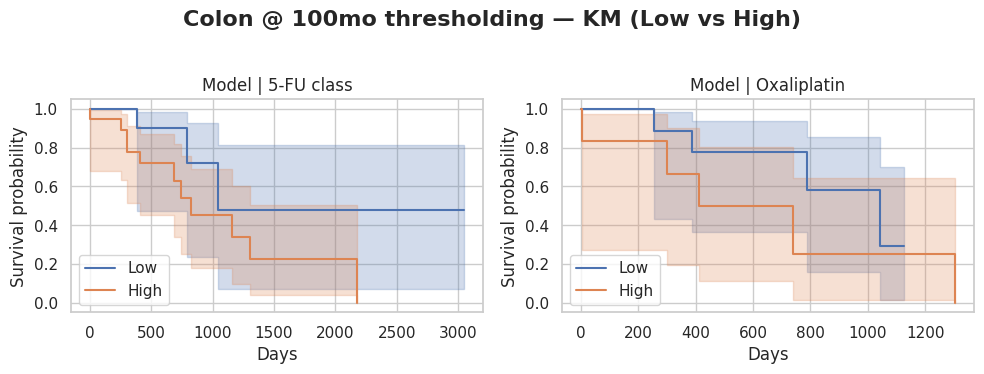


--- COLON: HRs (Cox) and counts ---


,,Cutoff,Cutoff_type,N,Events,HR,CI_low,CI_high,p_cox,High_N,Low_N,High_events_by_horizon,Low_events_by_horizon,p_logrank
Drug,Model,,,,,,,,,,,,,
5-FU class,Model,0.874899,TEST-Youden,31,14,1.983823,0.680065,5.787032,0.209807,19,12,11,3,0.158088
Oxaliplatin,Model,0.978771,TEST-Youden,16,9,1.783360,0.497882,6.387801,0.374184,6,10,5,4,0.319712



BREAST & LUNG — Drug-class cohorts: TEST-Youden (fallback to TEST-quantile), HR + KM


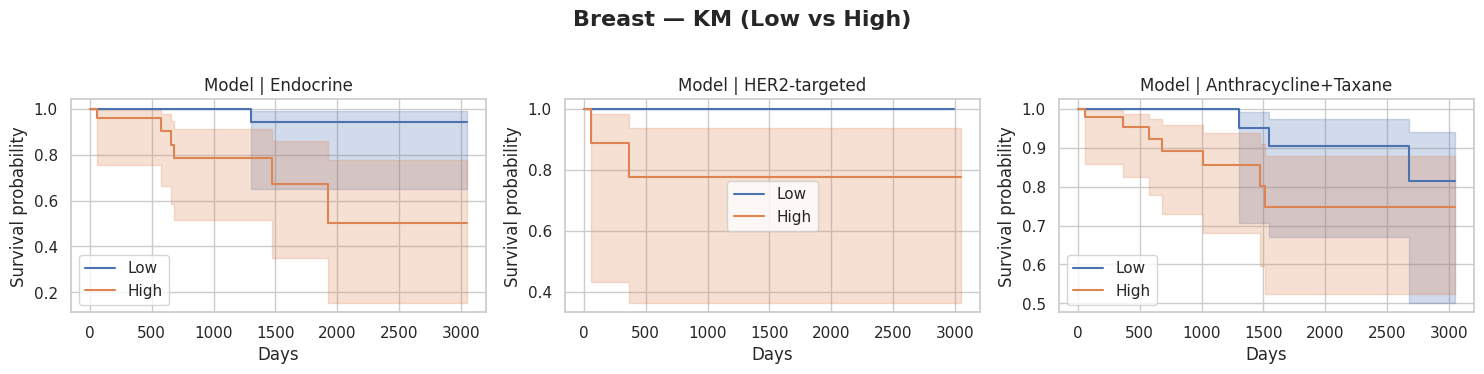


--- Breast: HRs (Cox) and counts ---


Cutoff  Cutoff_type   N  Events  \
Organ  Class                Model                                      
Breast Anthracycline+Taxane Model -0.339957  TEST-Youden  98      10   
       Endocrine            Model -0.234979  TEST-Youden  80       7   
       HER2-targeted        Model -0.339957  TEST-Youden  17       2   

                                         HR    CI_low   CI_high     p_cox  \
Organ  Class                Model                                           
Breast Anthracycline+Taxane Model  1.739315  0.717690  4.215216  0.220387   
       Endocrine            Model  3.224059  1.130031  9.198470  0.028633   
       HER2-targeted        Model       NaN       NaN       NaN       NaN   

                                   High_N  Low_N  High_events_by_horizon  \
Organ  Class                Model                                          
Breast Anthracycline+Taxane Model      47     51                       7   
       Endocrine            Model      26     54                       6   
       HER2-targeted        Model       9      8                       2   

                                   Low_events_by_horizon  p_logrank  
Organ  Class                Model                                    
Breast Anthracycline+Taxane Model                      3   0.079668  
       Endocrine            Model                      1   0.000754  
       HER2-targeted        Model                      0   0.169501

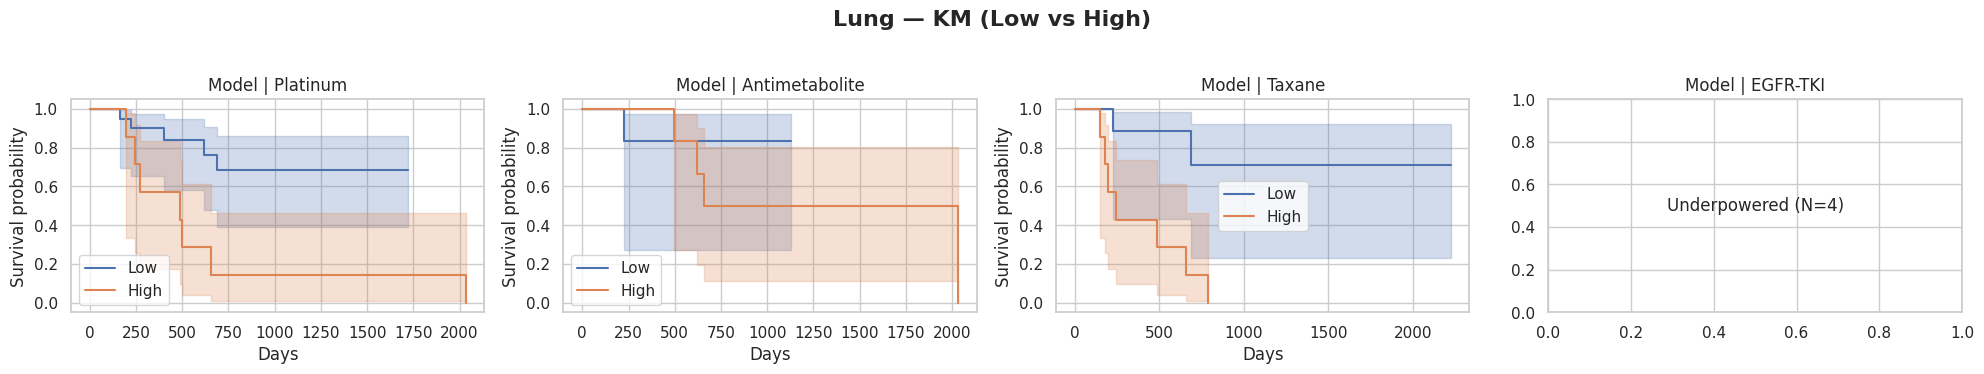


--- Lung: HRs (Cox) and counts ---


Cutoff  Cutoff_type   N  Events        HR  \
Organ Class          Model                                                
Lung  Antimetabolite Model  1.514591  TEST-Youden  12       5  1.470382   
      Platinum       Model  1.673698  TEST-Youden  28      12  3.586490   
      Taxane         Model  1.673698  TEST-Youden  16       9  5.338438   

                              CI_low    CI_high     p_cox  High_N  Low_N  \
Organ Class          Model                                                 
Lung  Antimetabolite Model  0.229796   9.408467  0.683936       6      6   
      Platinum       Model  1.210264  10.628191  0.021207       8     20   
      Taxane         Model  1.439459  19.798351  0.012256       7      9   

                            High_events_by_horizon  Low_events_by_horizon  \
Organ Class          Model                                                  
Lung  Antimetabolite Model                       4                      1   
      Platinum       Model                       7                      5   
      Taxane         Model                       7                      2   

                            p_logrank  
Organ Class          Model             
Lung  Antimetabolite Model   0.633190  
      Platinum       Model   0.005294  
      Taxane         Model   0.002608


--- Unique TEST patients per model ---


,Unique Patients
model_source,
Model,397


In [47]:
# ===========================
# Paper-style HRs and KMs
# ===========================
from pathlib import Path
import numpy as np, pandas as pd, re, warnings
from IPython.display import display
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# ------------------ CONFIG ------------------
TEST_PREDS_PATH = Path("eval_outputs/test_set.csv")  # patient-level aggregation handled below
TREATMENT_TSV   = Path("data/clinical.tsv")

organ_map = {
    'TCGA-COAD': 'Colon', 'TCGA-READ': 'Colon',
    'TCGA-BRCA': 'Breast',
    'TCGA-LUAD': 'Lung',  'TCGA-LUSC': 'Lung'
}

# Landmark used to build the ROC/Youden label (progressed by horizon)
HR_LANDMARK_MONTH  = 100
HR_LANDMARK_DAYS   = int(30.5 * HR_LANDMARK_MONTH)

# For HR fitting stability and power
MIN_N       = 10     # minimum cohort size to report
MIN_EVENTS  = 3      # minimum events to report
COX_PENAL   = 0.1    # small ridge to stabilize tiny strata
CENSOR_AT_HORIZON_FOR_HR = False  # set True to estimate HR "within 12 months"

# If Youden cannot be computed (all 0/1 by horizon), fallback to this TEST quantile:
QUANTILE_Q  = 0.80

# ------------------ HELPERS ------------------
def _ensure_model_source(df, default_name="Model"):
    if 'model_source' in df.columns: return df
    for alt in ['model','source','model_name']:
        if alt in df.columns: return df.rename(columns={alt:'model_source'})
    df = df.copy(); df['model_source'] = default_name; return df

def _agg_to_patient(slides_df):
    """Aggregate slide-level to patient-level."""
    agg = {'risk_score':'mean','time':'first','event':'first','dataset':'first','model_source':'first'}
    return slides_df.groupby('patient_id').agg(agg).reset_index()

def _add_organ(df):
    df = df.copy()
    df['organ'] = df['dataset'].map(organ_map).fillna('Other')
    return df

def _label_by_horizon(df, horizon_days=HR_LANDMARK_DAYS, time_col='time', event_col='event'):
    return ((df[event_col]==1) & (df[time_col] <= horizon_days)).astype(int)

def _youden_cutoff(scores, labels):
    s = np.asarray(scores); y = np.asarray(labels)
    if s.size==0 or y.size==0 or (y.sum()==0) or (y.sum()==y.size): return None
    fpr, tpr, thr = roc_curve(y, s, drop_intermediate=False)
    j = tpr - fpr
    if j.size==0 or np.all(np.isnan(j)): return None
    return float(thr[np.nanargmax(j)])

def _quantile_cutoff(scores, q):
    s = pd.Series(scores).dropna()
    return None if s.empty else float(s.quantile(q))

def _cox_hr_binary(df, group_col='group_high', time_col='time', event_col='event',
                   penalizer=COX_PENAL, horizon_days=None):
    """Cox PH HR with optional administrative censoring at horizon_days."""
    use = df[[time_col, event_col, group_col]].dropna().copy()
    if horizon_days is not None:
        use[event_col] = ((use[event_col]==1) & (use[time_col] <= horizon_days)).astype(int)
        use[time_col]  = np.minimum(use[time_col].values, horizon_days)
    use = use[use[time_col] > 0]
    n, events = int(len(use)), int(use[event_col].sum())
    if n < MIN_N or events < MIN_EVENTS or use[group_col].nunique() < 2:
        return {'N': n, 'Events': events, 'HR': np.nan, 'CI_low': np.nan, 'CI_high': np.nan, 'p': np.nan}
    cph = CoxPHFitter(penalizer=penalizer)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cph.fit(use, duration_col=time_col, event_col=event_col, show_progress=False)
    hr = float(cph.hazard_ratios_[group_col])
    lo, hi = cph.confidence_intervals_.loc[group_col].values.tolist()
    return {'N': n, 'Events': events, 'HR': hr, 'CI_low': float(np.exp(lo)), 'CI_high': float(np.exp(hi)),
            'p': float(cph.summary.loc[group_col,'p'])}

def _km_plot(df, ax, title, time_col='time', event_col='event', group_col='group_high', horizon_days=None):
    """KM curves for Low vs High groups; optional horizon censoring for display consistency."""
    d = df[[time_col,event_col,group_col]].dropna().copy()
    if horizon_days is not None:
        d[event_col] = ((d[event_col]==1) & (d[time_col] <= horizon_days)).astype(int)
        d[time_col]  = np.minimum(d[time_col].values, horizon_days)
    d = d[d[time_col]>0]
    if d[group_col].nunique()<2:
        ax.text(0.5,0.5,'Only one group present',ha='center',va='center'); ax.set_title(title); return np.nan
    km0, km1 = KaplanMeierFitter(), KaplanMeierFitter()
    g0, g1 = d[d[group_col]==0], d[d[group_col]==1]
    km0.fit(g0[time_col], event_observed=g0[event_col], label='Low')
    km1.fit(g1[time_col], event_observed=g1[event_col], label='High')
    km0.plot(ax=ax); km1.plot(ax=ax)
    ax.set_title(title); ax.set_xlabel('Days'); ax.set_ylabel('Survival probability')
    # log-rank p
    try:
        lr = logrank_test(g0[time_col], g1[time_col], event_observed_A=g0[event_col], event_observed_B=g1[event_col])
        return lr.p_value
    except Exception:
        return np.nan

# ------------------ DRUG NORMALIZATION ------------------
# (maps messy TCGA names to canonical drugs & drug-classes)
EXCLUDE_SUPPORTIVE = [
    'pegfilgrastim','filgrastim','denosumab','zoledronic','pamidronate','clodronate','ibandronate',
    'prednisone','dexamethasone','mesna','cyanocobalamin','palonosetron','clinical trial','trial agent',
    'vaccine','not reported','bcg solution'
]
SALT_TERMS = [' hydrochloride',' disodium',' acetate',' tartrate',' citrate',' liposomal',' pegylated',' nab-paclitaxel']
REGIMEN_EXPAND = {
    r'\bfolfox6?\b': '5-fluorouracil, leucovorin, oxaliplatin',
    r'\bm?folfiri\b': '5-fluorouracil, leucovorin, irinotecan',
    r'\bcapox\b|\bxelox\b': 'capecitabine, oxaliplatin',
    r'\bac[-\s]?t\b': 'doxorubicin, cyclophosphamide, paclitaxel',
    r'\btchp?\b': 'docetaxel, carboplatin, trastuzumab',
}
DRUG_SYNONYMS = {
    r'\b5\s*-\s*fu\b|\b5\s*fu\b|\bfluorouracil\b': '5-FU',
    r'\bcapecitabine\b|xeloda': 'Capecitabine',
    r'\boxaliplatin\b': 'Oxaliplatin',
    r'\bcisplatin\b': 'Cisplatin',
    r'\bcarboplatin\b': 'Carboplatin',
    r'\bpaclitaxel\b|taxol|nab[\s-]?paclitaxel|abraxane': 'Paclitaxel',
    r'\bdocetaxel\b|taxotere': 'Docetaxel',
    r'\bdoxorubicin\b|adriamycin': 'Doxorubicin',
    r'\bepirubicin\b': 'Epirubicin',
    r'\bgemcitabine\b': 'Gemcitabine',
    r'\bpemetrexed\b|alimta': 'Pemetrexed',
    r'\berlotinib\b|tarceva': 'Erlotinib',
    r'\bgefitinib\b|iressa': 'Gefitinib',
    r'\bbevacizumab\b|avastin': 'Bevacizumab',
    r'\btrastuzumab\b|herceptin': 'Trastuzumab',
    r'\btamoxifen\b': 'Tamoxifen',
    r'\banastrozole\b': 'Anastrozole',
    r'\bletrozole\b': 'Letrozole',
    r'\bexemestane\b': 'Exemestane',
    r'\birinotecan\b': 'Irinotecan',
    r'\bleucovorin\b|folinic acid': 'Leucovorin',
    r'\bsorafenib\b': 'Sorafenib',
}

def _normalize_drug_text(s: str) -> str:
    s = str(s or '').lower().strip()
    if any(k in s for k in EXCLUDE_SUPPORTIVE): return 'Supportive/Other'
    for pat, repl in REGIMEN_EXPAND.items(): s = re.sub(pat, repl, s)
    for term in SALT_TERMS: s = s.replace(term, '')
    s = re.sub(r'\s+', ' ', s).strip()
    found = []
    for tok in re.split(r'[;,/]| and |\+| with ', s):
        t = tok.strip()
        if not t: continue
        matched = False
        for pat, canon in DRUG_SYNONYMS.items():
            if re.search(pat, t): found.append(canon); matched=True; break
        if not matched and re.search(r'[a-z]', t): found.append(t.title())
    return ', '.join(dict.fromkeys(found)) if found else 'Unknown'

def _explode_drugs(pat_df, treatment_df):
    tx = treatment_df[['patient_id','treatment']].copy()
    tx['canon'] = tx['treatment'].apply(_normalize_drug_text)
    rows = []
    for pid, canon in tx[['patient_id','canon']].itertuples(index=False):
        for item in [c.strip() for c in canon.split(',') if c.strip()]:
            rows.append((pid, item))
    tx_exp = pd.DataFrame(rows, columns=['patient_id','drug'])
    merged = pat_df.merge(tx_exp, on='patient_id', how='left')
    merged['drug'] = merged['drug'].fillna('Unknown')
    return merged

# ------------------ LOAD TEST & TREATMENTS ------------------
test_slides = pd.read_csv(TEST_PREDS_PATH)
test_slides = _ensure_model_source(test_slides)
test_pat    = _add_organ(_agg_to_patient(test_slides))

treatment_df = pd.read_csv(TREATMENT_TSV, sep='\t', dtype=str)[['cases.submitter_id','treatments.therapeutic_agents']]
treatment_df = treatment_df.rename(columns={'cases.submitter_id':'patient_id','treatments.therapeutic_agents':'treatment'})
test_tx = _explode_drugs(test_pat, treatment_df)

# ------------------ COLON: paper-style per DRUG (Youden on TEST) ------------------
print("\n" + "="*80)
print("COLON (COAD/READ) — Paper-style per DRUG: TEST-derived Youden, HR + KM")
print("="*80)

# Define drugs-of-interest for colon (like the paper)
COLON_DRUG_COHORTS = {
    '5-FU class': lambda d: d['drug'].isin(['5-FU','Capecitabine']),
    'Oxaliplatin': lambda d: d['drug'].eq('Oxaliplatin'),
}

colon_df = test_tx[test_tx['organ']=='Colon'].copy()

def _fit_and_report_per_drug(colon_df, cohorts, title_prefix):
    all_rows = []
    # KM figure layout (models × drugs)
    models = sorted(colon_df['model_source'].unique())
    drugs  = list(cohorts.keys())
    nrows, ncols = len(models), len(drugs)
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5*ncols, 3.8*nrows), squeeze=False)
    fig.suptitle(f"{title_prefix} — KM (Low vs High)", fontsize=16, weight='bold')

    for i, model in enumerate(models):
        g_model = colon_df[colon_df['model_source']==model]
        for j, (drug_name, filt_fn) in enumerate(cohorts.items()):
            g = g_model[filt_fn(g_model)]
            # collapse to unique patients (multiple drug rows collapse via any exposure)
            g = g.drop_duplicates(subset=['patient_id'])
            # power check
            if len(g) < MIN_N:
                axes[i,j].text(0.5,0.5,f'Underpowered (N={len(g)})',ha='center',va='center'); axes[i,j].set_title(f'{model} | {drug_name}'); continue
            # Youden on TEST at horizon
            y = _label_by_horizon(g, HR_LANDMARK_DAYS)
            thr = _youden_cutoff(g['risk_score'], y)
            cutoff_type = 'TEST-Youden'
            if thr is None:
                thr = _quantile_cutoff(g['risk_score'], QUANTILE_Q)
                cutoff_type = f'TEST-quantile(q={QUANTILE_Q})'
            g['group_high'] = (g['risk_score'] >= thr).astype(int)

            # HR (optionally landmarked)
            hr = _cox_hr_binary(g, group_col='group_high',
                                horizon_days=(HR_LANDMARK_DAYS if CENSOR_AT_HORIZON_FOR_HR else None))
            # KM + log-rank
            p_lr = _km_plot(g, axes[i,j], title=f'{model} | {drug_name}',
                            horizon_days=(HR_LANDMARK_DAYS if CENSOR_AT_HORIZON_FOR_HR else None))
            # counts @ horizon
            lbl = _label_by_horizon(g, HR_LANDMARK_DAYS)
            is_high = g['group_high'].values.astype(int)
            row = {
                'Model': model, 'Drug': drug_name, 'Cutoff': thr, 'Cutoff_type': cutoff_type,
                'N': hr['N'], 'Events': hr['Events'], 'HR': hr['HR'],
                'CI_low': hr['CI_low'], 'CI_high': hr['CI_high'], 'p_cox': hr['p'],
                'High_N': int(is_high.sum()), 'Low_N': int((1-is_high).sum()),
                'High_events_by_horizon': int(((lbl==1) & (is_high==1)).sum()),
                'Low_events_by_horizon':  int(((lbl==1) & (is_high==0)).sum()),
                'p_logrank': p_lr
            }
            all_rows.append(row)
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()
    res = pd.DataFrame(all_rows).sort_values(['Drug','Model']).set_index(['Drug','Model'])
    print("\n--- COLON: HRs (Cox) and counts ---")
    display(res[['Cutoff','Cutoff_type','N','Events','HR','CI_low','CI_high','p_cox',
                 'High_N','Low_N','High_events_by_horizon','Low_events_by_horizon','p_logrank']])
    return res

colon_results = _fit_and_report_per_drug(colon_df, COLON_DRUG_COHORTS, title_prefix=f'Colon @ {HR_LANDMARK_MONTH}mo thresholding')

# ------------------ BREAST & LUNG: larger drug-classes (TEST Youden with fallback) ------------------
print("\n" + "="*80)
print("BREAST & LUNG — Drug-class cohorts: TEST-Youden (fallback to TEST-quantile), HR + KM")
print("="*80)

# Biologically meaningful classes with typically larger N
CLASS_RULES = {
    'Breast': {
        'Endocrine':      lambda d: d['drug'].isin(['Tamoxifen','Anastrozole','Letrozole','Exemestane']),
        'HER2-targeted':  lambda d: d['drug'].isin(['Trastuzumab']),
        'Anthracycline+Taxane': lambda d: d['drug'].isin(['Doxorubicin','Epirubicin','Paclitaxel','Docetaxel']),
    },
    'Lung': {
        'Platinum':       lambda d: d['drug'].isin(['Cisplatin','Carboplatin','Oxaliplatin']),
        'Antimetabolite': lambda d: d['drug'].isin(['Gemcitabine','Pemetrexed']),
        'Taxane':         lambda d: d['drug'].isin(['Paclitaxel','Docetaxel']),
        'EGFR-TKI':       lambda d: d['drug'].isin(['Erlotinib','Gefitinib']),
    }
}

def _fit_and_report_by_class(test_tx, organ_name, class_rules):
    df = test_tx[test_tx['organ']==organ_name].copy()
    if df.empty:
        print(f"\nNo {organ_name} patients."); return pd.DataFrame()
    models = sorted(df['model_source'].unique())
    classes = list(class_rules.keys())
    fig, axes = plt.subplots(nrows=len(models), ncols=len(classes), figsize=(5*len(classes), 3.8*len(models)), squeeze=False)
    fig.suptitle(f"{organ_name} — KM (Low vs High)", fontsize=16, weight='bold')
    out = []

    for i, model in enumerate(models):
        g_model = df[df['model_source']==model]
        for j, (cls_name, filt_fn) in enumerate(class_rules.items()):
            gg = g_model[filt_fn(g_model)].drop_duplicates(subset=['patient_id'])
            if len(gg) < MIN_N:
                axes[i,j].text(0.5,0.5,f'Underpowered (N={len(gg)})',ha='center',va='center'); axes[i,j].set_title(f'{model} | {cls_name}'); continue
            y = _label_by_horizon(gg, HR_LANDMARK_DAYS)
            thr = _youden_cutoff(gg['risk_score'], y)
            cutoff_type = 'TEST-Youden'
            if thr is None:
                thr = _quantile_cutoff(gg['risk_score'], QUANTILE_Q)
                cutoff_type = f'TEST-quantile(q={QUANTILE_Q})'
            gg['group_high'] = (gg['risk_score'] >= thr).astype(int)
            hr = _cox_hr_binary(gg, group_col='group_high',
                                horizon_days=(HR_LANDMARK_DAYS if CENSOR_AT_HORIZON_FOR_HR else None))
            p_lr = _km_plot(gg, axes[i,j], title=f'{model} | {cls_name}',
                            horizon_days=(HR_LANDMARK_DAYS if CENSOR_AT_HORIZON_FOR_HR else None))
            lbl = _label_by_horizon(gg, HR_LANDMARK_DAYS); is_high = gg['group_high'].values.astype(int)
            out.append({
                'Organ': organ_name, 'Model': model, 'Class': cls_name,
                'Cutoff': thr, 'Cutoff_type': cutoff_type,
                'N': hr['N'], 'Events': hr['Events'], 'HR': hr['HR'],
                'CI_low': hr['CI_low'], 'CI_high': hr['CI_high'], 'p_cox': hr['p'],
                'High_N': int(is_high.sum()), 'Low_N': int((1-is_high).sum()),
                'High_events_by_horizon': int(((lbl==1) & (is_high==1)).sum()),
                'Low_events_by_horizon':  int(((lbl==1) & (is_high==0)).sum()),
                'p_logrank': p_lr
            })
    plt.tight_layout(rect=[0,0,1,0.95]); plt.show()
    res = pd.DataFrame(out).sort_values(['Organ','Class','Model']).set_index(['Organ','Class','Model'])
    print(f"\n--- {organ_name}: HRs (Cox) and counts ---")
    display(res[['Cutoff','Cutoff_type','N','Events','HR','CI_low','CI_high','p_cox',
                 'High_N','Low_N','High_events_by_horizon','Low_events_by_horizon','p_logrank']])
    return res

breast_results = _fit_and_report_by_class(test_tx, 'Breast', CLASS_RULES['Breast'])
lung_results   = _fit_and_report_by_class(test_tx, 'Lung',   CLASS_RULES['Lung'])

# ------------------ Quick sanity: TEST patient counts per model ------------------
print("\n--- Unique TEST patients per model ---")
display(test_pat.groupby('model_source')['patient_id'].nunique().rename('Unique Patients').to_frame())

In [53]:
# ===========================
# Side-by-side: TEST-Youden@100m vs VAL-Youden->TEST@12m vs TEST-Quantile
# ===========================
from pathlib import Path
import numpy as np, pandas as pd, re, warnings
from IPython.display import display
from sklearn.metrics import roc_curve
from lifelines import CoxPHFitter

# ---------------- CONFIG ----------------
VAL_PREDS_PATH  = Path("eval_outputs/val_set.csv")
TEST_PREDS_PATH = Path("eval_outputs/test_set.csv")
TREATMENT_TSV   = Path("data/clinical.tsv")

organ_map = {
    'TCGA-COAD': 'Colon', 'TCGA-READ': 'Colon',
    'TCGA-BRCA': 'Breast',
    'TCGA-LUAD': 'Lung',  'TCGA-LUSC': 'Lung'
}

# Strategy horizons (in months)
STRAT_TEST_YOUDEN_MONTHS = 100   # exploratory, like your run
STRAT_VAL_YOUDEN_MONTHS  = 12    # primary, leak-free
QUANTILE_Q = 0.5                # test-quantile split

# HR fitting / reporting knobs
HR_CENSOR_WITHIN_HORIZON = False  # keep False to match your current HRs (full follow-up)
MIN_N      = 10                   # min N to attempt HR
MIN_EVENTS = 3                    # min events to attempt HR
COX_PENAL  = 0.1                  # small ridge for stability

# ---------------- HELPERS ----------------
def _ensure_model_source(df, default_name="Model"):
    if 'model_source' in df.columns: return df
    for alt in ['model','source','model_name']:
        if alt in df.columns: return df.rename(columns={alt:'model_source'})
    df = df.copy(); df['model_source'] = default_name; return df

def _agg_to_patient(slides_df):
    agg = {'risk_score':'mean','time':'first','event':'first','dataset':'first','model_source':'first'}
    return slides_df.groupby('patient_id').agg(agg).reset_index()

def _add_organ(df):
    df = df.copy(); df['organ'] = df['dataset'].map(organ_map).fillna('Other'); return df

def _label_by_horizon(df, horizon_days, time_col='time', event_col='event'):
    return ((df[event_col]==1) & (df[time_col] <= horizon_days)).astype(int)

def _youden_cutoff(scores, labels):
    s = np.asarray(scores); y = np.asarray(labels)
    if s.size==0 or y.size==0 or (y.sum()==0) or (y.sum()==y.size): return None
    fpr, tpr, thr = roc_curve(y, s, drop_intermediate=False)
    j = tpr - fpr
    if j.size==0 or np.all(np.isnan(j)): return None
    return float(thr[np.nanargmax(j)])

def _quantile_cutoff(scores, q):
    s = pd.Series(scores).dropna()
    return None if s.empty else float(s.quantile(q))

def _cox_hr_binary(df, group_col='group_high', time_col='time', event_col='event',
                   penalizer=COX_PENAL, horizon_days=None):
    """Cox PH HR with optional admin censoring at horizon_days."""
    use = df[[time_col, event_col, group_col]].dropna().copy()
    if horizon_days is not None:
        use[event_col] = ((use[event_col]==1) & (use[time_col] <= horizon_days)).astype(int)
        use[time_col]  = np.minimum(use[time_col].values, horizon_days)
    use = use[use[time_col] > 0]
    n, events = int(len(use)), int(use[event_col].sum())
    if n < MIN_N or events < MIN_EVENTS or use[group_col].nunique() < 2:
        return {'N': n, 'Events': events, 'HR': np.nan, 'CI_low': np.nan, 'CI_high': np.nan, 'p': np.nan}
    cph = CoxPHFitter(penalizer=penalizer)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        cph.fit(use, duration_col=time_col, event_col=event_col, show_progress=False)
    hr = float(cph.hazard_ratios_[group_col])
    lo, hi = cph.confidence_intervals_.loc[group_col].values.tolist()
    return {'N': n, 'Events': events, 'HR': hr,
            'CI_low': float(np.exp(lo)), 'CI_high': float(np.exp(hi)),
            'p': float(cph.summary.loc[group_col,'p'])}

# ---- Drug text normalization (same spirit as before) ----
EXCLUDE_SUPPORTIVE = [
    'pegfilgrastim','filgrastim','denosumab','zoledronic','pamidronate','clodronate','ibandronate',
    'prednisone','dexamethasone','mesna','cyanocobalamin','palonosetron','clinical trial','trial agent',
    'vaccine','not reported','bcg solution'
]
SALT_TERMS = [' hydrochloride',' disodium',' acetate',' tartrate',' citrate',' liposomal',' pegylated',' nab-paclitaxel']
REGIMEN_EXPAND = {
    r'\bfolfox6?\b': '5-fluorouracil, leucovorin, oxaliplatin',
    r'\bm?folfiri\b': '5-fluorouracil, leucovorin, irinotecan',
    r'\bcapox\b|\bxelox\b': 'capecitabine, oxaliplatin',
    r'\bac[-\s]?t\b': 'doxorubicin, cyclophosphamide, paclitaxel',
    r'\btchp?\b': 'docetaxel, carboplatin, trastuzumab',
}
DRUG_SYNONYMS = {
    r'\b5\s*-\s*fu\b|\b5\s*fu\b|\bfluorouracil\b': '5-FU',
    r'\bcapecitabine\b|xeloda': 'Capecitabine',
    r'\boxaliplatin\b': 'Oxaliplatin',
    r'\bcisplatin\b': 'Cisplatin',
    r'\bcarboplatin\b': 'Carboplatin',
    r'\bpaclitaxel\b|taxol|nab[\s-]?paclitaxel|abraxane': 'Paclitaxel',
    r'\bdocetaxel\b|taxotere': 'Docetaxel',
    r'\bdoxorubicin\b|adriamycin': 'Doxorubicin',
    r'\bepirubicin\b': 'Epirubicin',
    r'\bgemcitabine\b': 'Gemcitabine',
    r'\bpemetrexed\b|alimta': 'Pemetrexed',
    r'\berlotinib\b|tarceva': 'Erlotinib',
    r'\bgefitinib\b|iressa': 'Gefitinib',
    r'\bbevacizumab\b|avastin': 'Bevacizumab',
    r'\btrastuzumab\b|herceptin': 'Trastuzumab',
    r'\btamoxifen\b': 'Tamoxifen',
    r'\banastrozole\b': 'Anastrozole',
    r'\bletrozole\b': 'Letrozole',
    r'\bexemestane\b': 'Exemestane',
    r'\birinotecan\b': 'Irinotecan',
    r'\bleucovorin\b|folinic acid': 'Leucovorin',
    r'\bsorafenib\b': 'Sorafenib',
}

def _normalize_drug_text(s: str) -> str:
    s = str(s or '').lower().strip()
    if any(k in s for k in EXCLUDE_SUPPORTIVE): return 'Supportive/Other'
    for pat, repl in REGIMEN_EXPAND.items(): s = re.sub(pat, repl, s)
    for term in SALT_TERMS: s = s.replace(term, '')
    s = re.sub(r'\s+', ' ', s).strip()
    found = []
    for tok in re.split(r'[;,/]| and |\+| with ', s):
        t = tok.strip()
        if not t: continue
        matched = False
        for pat, canon in DRUG_SYNONYMS.items():
            if re.search(pat, t): found.append(canon); matched=True; break
        if not matched and re.search(r'[a-z]', t): found.append(t.title())
    return ', '.join(dict.fromkeys(found)) if found else 'Unknown'

def _explode_drugs(pat_df, treatment_df):
    tx = treatment_df[['patient_id','treatment']].copy()
    tx['canon'] = tx['treatment'].apply(_normalize_drug_text)
    rows = []
    for pid, canon in tx[['patient_id','canon']].itertuples(index=False):
        for item in [c.strip() for c in canon.split(',') if c.strip()]:
            rows.append((pid, item))
    tx_exp = pd.DataFrame(rows, columns=['patient_id','drug'])
    return pat_df.merge(tx_exp, on='patient_id', how='left').assign(
        drug=lambda d: d['drug'].fillna('Unknown')
    )

# ---------------- LOAD VAL/TEST & MAP DRUGS ----------------
val_slides  = pd.read_csv(VAL_PREDS_PATH)
test_slides = pd.read_csv(TEST_PREDS_PATH)
val_pat  = _add_organ(_agg_to_patient(_ensure_model_source(val_slides)))
test_pat = _add_organ(_agg_to_patient(_ensure_model_source(test_slides)))

treatment_df = pd.read_csv(TREATMENT_TSV, sep='\t', dtype=str)[['cases.submitter_id','treatments.therapeutic_agents']]
treatment_df = treatment_df.rename(columns={'cases.submitter_id':'patient_id','treatments.therapeutic_agents':'treatment'})

val_tx  = _explode_drugs(val_pat,  treatment_df)
test_tx = _explode_drugs(test_pat, treatment_df)

# Focus organs
focus_orgs = ['Colon','Breast','Lung']
val_tx  = val_tx[val_tx['organ'].isin(focus_orgs)]
test_tx = test_tx[test_tx['organ'].isin(focus_orgs)]

# ---------------- Cohort definitions ----------------
COLON_COHORTS = {  # per drug (paper-style)
    '5-FU class': lambda d: d['drug'].isin(['5-FU','Capecitabine']),
    'Oxaliplatin': lambda d: d['drug'].eq('Oxaliplatin'),
}
BREAST_CLASSES = {
    'Endocrine': lambda d: d['drug'].isin(['Tamoxifen','Anastrozole','Letrozole','Exemestane']),
    'HER2-targeted': lambda d: d['drug'].isin(['Trastuzumab']),
    'Anthracycline+Taxane': lambda d: d['drug'].isin(['Doxorubicin','Epirubicin','Paclitaxel','Docetaxel']),
}
LUNG_CLASSES = {
    'Platinum':       lambda d: d['drug'].isin(['Cisplatin','Carboplatin','Oxaliplatin']),
    'Antimetabolite': lambda d: d['drug'].isin(['Gemcitabine','Pemetrexed']),
    'Taxane':         lambda d: d['drug'].isin(['Paclitaxel','Docetaxel']),
    'EGFR-TKI':       lambda d: d['drug'].isin(['Erlotinib','Gefitinib']),
}

# util to get cohort subset & dedupe patients
def _subset(test_or_val_df, organ, filt_fn):
    sub = test_or_val_df[test_or_val_df['organ']==organ]
    sub = sub[filt_fn(sub)].drop_duplicates('patient_id')
    return sub

# ---------- Strategy runners ----------
def _compute_strategy(test_df, val_df, organ, cohorts: dict, strategy_label: str,
                      strat_horizon_months: int | None, use_val_for_cutoff: bool,
                      quantile_q: float | None):
    """Return list of rows with HRs & counts for each model×cohort for a strategy."""
    rows = []
    H = None if strat_horizon_months is None else int(30.5 * strat_horizon_months)
    for model in sorted(test_df['model_source'].unique()):
        test_m = test_df[(test_df['organ']==organ) & (test_df['model_source']==model)]
        val_m  = val_df[(val_df['organ']==organ) & (val_df['model_source']==model)]
        for cohort_name, filt_fn in cohorts.items():
            test_cohort = _subset(test_m, organ, filt_fn)
            if len(test_cohort) == 0:
                rows.append({'Organ': organ,'Cohort': cohort_name,'Model': model,'Strategy': strategy_label,
                             'Cutoff': np.nan,'Cutoff_type': 'NA','N':0,'Events':0,'HR':np.nan,
                             'CI_low':np.nan,'CI_high':np.nan,'p_cox':np.nan,
                             'High_N':0,'Low_N':0,'High_events_by_horizon':0,'Low_events_by_horizon':0})
                continue

            # choose cutoff
            cutoff_type = ''
            if use_val_for_cutoff:
                val_cohort = _subset(val_m, organ, filt_fn)
                thr = None
                if strat_horizon_months is not None:
                    yv = _label_by_horizon(val_cohort, H); thr = _youden_cutoff(val_cohort['risk_score'], yv)
                    cutoff_type = f'VAL-Youden@{strat_horizon_months}m'
                if thr is None and quantile_q is not None:
                    thr = _quantile_cutoff(val_cohort['risk_score'], quantile_q)
                    cutoff_type = f'VAL-quantile(q={quantile_q})'
            else:
                thr = None
                if strat_horizon_months is not None and quantile_q is None:
                    yt = _label_by_horizon(test_cohort, H); thr = _youden_cutoff(test_cohort['risk_score'], yt)
                    cutoff_type = f'TEST-Youden@{strat_horizon_months}m'
                if (thr is None) and (quantile_q is not None):
                    thr = _quantile_cutoff(test_cohort['risk_score'], quantile_q)
                    cutoff_type = f'TEST-quantile(q={quantile_q})'

            if thr is None or pd.isna(thr):
                rows.append({'Organ': organ,'Cohort': cohort_name,'Model': model,'Strategy': strategy_label,
                             'Cutoff': np.nan,'Cutoff_type': 'NA','N':len(test_cohort),
                             'Events': int(test_cohort['event'].sum()),'HR':np.nan,'CI_low':np.nan,'CI_high':np.nan,'p_cox':np.nan,
                             'High_N':0,'Low_N':0,'High_events_by_horizon':0,'Low_events_by_horizon':0})
                continue

            d = test_cohort.copy()
            d['group_high'] = (d['risk_score'] >= thr).astype(int)

            # HR (with/without horizon censoring for the estimate itself)
            hr = _cox_hr_binary(d, group_col='group_high',
                                horizon_days=(H if HR_CENSOR_WITHIN_HORIZON else None))

            # counts at strat horizon (for comparability)
            if H is not None:
                lbl = _label_by_horizon(d, H)
            else:
                # if no horizon, still report within 12 months as a fixed ref? we'll use H here anyway; when None -> 12m counts are not relevant
                lbl = pd.Series(np.zeros(len(d), dtype=int), index=d.index)
            is_high = d['group_high'].astype(int).values

            rows.append({
                'Organ': organ, 'Cohort': cohort_name, 'Model': model, 'Strategy': strategy_label,
                'Cutoff': float(thr), 'Cutoff_type': cutoff_type,
                'N': hr['N'], 'Events': hr['Events'], 'HR': hr['HR'],
                'CI_low': hr['CI_low'], 'CI_high': hr['CI_high'], 'p_cox': hr['p'],
                'High_N': int(is_high.sum()), 'Low_N': int((1-is_high).sum()),
                'High_events_by_horizon': int(((lbl==1) & (is_high==1)).sum()),
                'Low_events_by_horizon':  int(((lbl==1) & (is_high==0)).sum()),
            })
    return rows

# ---------- Run 3 strategies per organ ----------
def run_all_strategies():
    all_rows = []
    # A) TEST-Youden @ 100m (exploratory)
    for organ, cohorts in [('Colon', COLON_COHORTS), ('Breast', BREAST_CLASSES), ('Lung', LUNG_CLASSES)]:
        all_rows += _compute_strategy(test_tx, val_tx, organ, cohorts,
                                      strategy_label='A_TEST-Youden@100m',
                                      strat_horizon_months=STRAT_TEST_YOUDEN_MONTHS,
                                      use_val_for_cutoff=False, quantile_q=None)
    # B) VAL-Youden -> TEST @ 12m (primary)
    for organ, cohorts in [('Colon', COLON_COHORTS), ('Breast', BREAST_CLASSES), ('Lung', LUNG_CLASSES)]:
        all_rows += _compute_strategy(test_tx, val_tx, organ, cohorts,
                                      strategy_label='B_VAL-Youden@12m→TEST',
                                      strat_horizon_months=STRAT_VAL_YOUDEN_MONTHS,
                                      use_val_for_cutoff=True, quantile_q=QUANTILE_Q)  # fallback to val quantile if needed
    # C) TEST-Quantile (unsupervised)
    for organ, cohorts in [('Colon', COLON_COHORTS), ('Breast', BREAST_CLASSES), ('Lung', LUNG_CLASSES)]:
        all_rows += _compute_strategy(test_tx, val_tx, organ, cohorts,
                                      strategy_label=f'C_TEST-quantile(q={QUANTILE_Q})',
                                      strat_horizon_months=None,
                                      use_val_for_cutoff=False, quantile_q=QUANTILE_Q)
    return pd.DataFrame(all_rows)

compare_df = run_all_strategies()

# ---------------- Pretty side-by-side pivots ----------------
idx = ['Organ','Cohort','Model']
print("\n=== Side-by-side HR / CI / p (by Strategy) ===")
hr_pivot = compare_df.pivot_table(index=idx, columns='Strategy',
                                  values=['HR','CI_low','CI_high','p_cox'])
display(hr_pivot.sort_index())

print("\n=== Side-by-side group sizes & horizon event counts (by Strategy) ===")
cnt_pivot = compare_df.pivot_table(index=idx, columns='Strategy',
                                   values=['N','High_N','Low_N','High_events_by_horizon','Low_events_by_horizon'])
display(cnt_pivot.sort_index())

print("\n=== Cutoff values (by Strategy) ===")
cut_pivot = compare_df.pivot_table(index=idx, columns='Strategy', values=['Cutoff'])
display(cut_pivot.sort_index())

# Optional: show how many unique TEST patients per model (sanity)
print("\n--- Unique TEST patients per model ---")
display(test_pat.groupby('model_source')['patient_id'].nunique().rename('Unique Patients').to_frame())


=== Side-by-side HR / CI / p (by Strategy) ===


CI_high                        \
Strategy                          A_TEST-Youden@100m B_VAL-Youden@12m→TEST   
Organ  Cohort               Model                                            
Breast Anthracycline+Taxane Model           4.215216              3.577129   
       Endocrine            Model           9.198470              6.140018   
Colon  5-FU class           Model           5.787032              4.630593   
       Oxaliplatin          Model           6.387801              5.802199   
Lung   Antimetabolite       Model           9.408467             11.486893   
       Platinum             Model          10.628191             14.625185   
       Taxane               Model          19.798351             19.190598   

                                                                     CI_low  \
Strategy                          C_TEST-quantile(q=0.5) A_TEST-Youden@100m   
Organ  Cohort               Model                                             
Breast Anthracycline+Taxane Model               4.176431           0.717690   
       Endocrine            Model               6.448898           1.130031   
Colon  5-FU class           Model               4.309123           0.680065   
       Oxaliplatin          Model               9.035104           0.497882   
Lung   Antimetabolite       Model               9.408467           0.229796   
       Platinum             Model               8.200354           1.210264   
       Taxane               Model              17.692531           1.439459   

                                                         \
Strategy                          B_VAL-Youden@12m→TEST   
Organ  Cohort               Model                         
Breast Anthracycline+Taxane Model              0.588975   
       Endocrine            Model              0.755185   
Colon  5-FU class           Model              0.420199   
       Oxaliplatin          Model              0.404472   
Lung   Antimetabolite       Model              0.181107   
       Platinum             Model              0.958034   
       Taxane               Model              0.705839   

                                                                         HR  \
Strategy                          C_TEST-quantile(q=0.5) A_TEST-Youden@100m   
Organ  Cohort               Model                                             
Breast Anthracycline+Taxane Model               0.710800           1.739315   
       Endocrine            Model               0.825982           3.224059   
Colon  5-FU class           Model               0.593891           1.983823   
       Oxaliplatin          Model               0.687535           1.783360   
Lung   Antimetabolite       Model               0.229796           1.470382   
       Platinum             Model               0.899442           3.586490   
       Taxane               Model               1.247921           5.338438   

                                                         \
Strategy                          B_VAL-Youden@12m→TEST   
Organ  Cohort               Model                         
Breast Anthracycline+Taxane Model              1.451496   
       Endocrine            Model              2.153334   
Colon  5-FU class           Model              1.394909   
       Oxaliplatin          Model              1.531936   
Lung   Antimetabolite       Model              1.442343   
       Platinum             Model              3.743184   
       Taxane               Model              3.680416   

                                                                      p_cox  \
Strategy                          C_TEST-quantile(q=0.5) A_TEST-Youden@100m   
Organ  Cohort               Model                                             
Breast Anthracycline+Taxane Model               1.722965           0.220387   
       Endocrine            Model               2.307959           0.028633   
Colon  5-FU class           Model               1.599734           0.209807   
       Oxaliplatin        


=== Side-by-side group sizes & horizon event counts (by Strategy) ===


High_N                        \
Strategy                          A_TEST-Youden@100m B_VAL-Youden@12m→TEST   
Organ  Cohort               Model                                            
Breast Anthracycline+Taxane Model               47.0                  59.0   
       Endocrine            Model               26.0                  46.0   
       HER2-targeted        Model                9.0                  11.0   
Colon  5-FU class           Model               19.0                   6.0   
       Oxaliplatin          Model                6.0                   5.0   
Lung   Antimetabolite       Model                6.0                   2.0   
       EGFR-TKI             Model                0.0                   4.0   
       Platinum             Model                8.0                   4.0   
       Taxane               Model                7.0                   2.0   

                                                          \
Strategy                          C_TEST-quantile(q=0.5)   
Organ  Cohort               Model                          
Breast Anthracycline+Taxane Model                   49.0   
       Endocrine            Model                   40.0   
       HER2-targeted        Model                    9.0   
Colon  5-FU class           Model                   16.0   
       Oxaliplatin          Model                    8.0   
Lung   Antimetabolite       Model                    6.0   
       EGFR-TKI             Model                    2.0   
       Platinum             Model                   14.0   
       Taxane               Model                    8.0   

                                  High_events_by_horizon  \
Strategy                              A_TEST-Youden@100m   
Organ  Cohort               Model                          
Breast Anthracycline+Taxane Model                    7.0   
       Endocrine            Model                    6.0   
       HER2-targeted        Model                    2.0   
Colon  5-FU class           Model                   11.0   
       Oxaliplatin          Model                    5.0   
Lung   Antimetabolite       Model                    4.0   
       EGFR-TKI             Model                    0.0   
       Platinum             Model                    7.0   
       Taxane               Model                    7.0   

                                                         \
Strategy                          B_VAL-Youden@12m→TEST   
Organ  Cohort               Model                         
Breast Anthracycline+Taxane Model                   2.0   
       Endocrine            Model                   1.0   
       HER2-targeted        Model                   2.0   
Colon  5-FU class           Model                   1.0   
       Oxaliplatin          Model                   2.0   
Lung   Antimetabolite       Model                   0.0   
       EGFR-TKI             Model                   1.0   
       Platinum             Model                   1.0   
       Taxane               Model                   1.0   

                                                                      Low_N  \
Strategy                          C_TEST-quantile(q=0.5) A_TEST-Youden@100m   
Organ  Cohort               Model                                             
Breast Anthracycline+Taxane Model                    0.0               51.0   
       Endocrine            Model                    0.0               54.0   
       HER2-targeted        Model                    0.0                8.0   
Colon  5-FU class           Model                    0.0               12.0   
       Oxaliplatin          Model                    0.0               10.0   
Lung   Antimetabolite       Model                    0.0                6.0   
       EGFR-TKI             Model                    0.0                0.0   
       Platinum             Model                    0.0               20.0   
       Taxane               Model                    0.0                9.0   

         


=== Cutoff values (by Strategy) ===


Cutoff                        \
Strategy                          A_TEST-Youden@100m B_VAL-Youden@12m→TEST   
Organ  Cohort               Model                                            
Breast Anthracycline+Taxane Model          -0.339957             -0.529752   
       Endocrine            Model          -0.234979             -0.714168   
       HER2-targeted        Model          -0.339957             -0.498304   
Colon  5-FU class           Model           0.874899              1.433596   
       Oxaliplatin          Model           0.978771              1.025088   
Lung   Antimetabolite       Model           1.514591              2.011710   
       EGFR-TKI             Model                NaN              1.376241   
       Platinum             Model           1.673698              1.969998   
       Taxane               Model           1.673698              2.011710   

                                                          
Strategy                          C_TEST-quantile(q=0.5)  
Organ  Cohort               Model                         
Breast Anthracycline+Taxane Model              -0.372132  
       Endocrine            Model              -0.511860  
       HER2-targeted        Model              -0.339957  
Colon  5-FU class           Model               0.949718  
       Oxaliplatin          Model               0.847643  
Lung   Antimetabolite       Model               1.451875  
       EGFR-TKI             Model               1.986200  
       Platinum             Model               1.300258  
       Taxane               Model               1.342039


--- Unique TEST patients per model ---


,Unique Patients
model_source,
Model,397
